In [3]:
#!/usr/bin/env python
"""
LeafletFA Model Evaluation in Mouse 

This script:
1. Loads trained LeafletFA model outputs and associated data (mouse foundation smart-seq data)
2. Load the human foundation data and map junctions to human (via list of conserved junctions)
3. Apply the model to the human data
4. Save the predicted factor activities and factor usage
"""

import os
import sys
import glob
import pickle
import gzip
import warnings
from pathlib import Path
from collections import defaultdict
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from pyfaidx import Fasta

# Data analysis libraries
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp
from scipy.stats import spearmanr, pearsonr
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import linkage, dendrogram
import scanpy as sc
import umap

# Machine learning libraries
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import (mean_squared_error, accuracy_score, r2_score, 
                           classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

# Statistical modeling
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from mord import OrdinalRidge

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter
from adjustText import adjust_text

# Single-cell analysis libraries
import anndata as ad
import scanpy as sc

# Bioinformatics libraries
import gffutils
from tqdm import tqdm

# PyTorch setup
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device count:", torch.cuda.device_count())
    print("CUDA device name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.set_default_tensor_type("torch.FloatTensor" if device.type == "cpu" else "torch.cuda.FloatTensor")
torch.manual_seed(0)

# Configure plotting and warnings
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')
warnings.filterwarnings('ignore')

# =============================================================================
# Custom Module Imports
# =============================================================================

# Add custom module paths
leaflet_src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"
utils_path = "/gpfs/commons/home/kisaev/LeafletFA_Submission2025/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/"

for path in [leaflet_src_path, utils_path]:
    if path not in sys.path:
        sys.path.append(path)

# Import utility functions
from utils import *

Torch version: 2.4.1.post300
CUDA available: False
Using device: cpu


In [4]:
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/LeafletFA_Submission2025/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"
MODEL_FILES = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning"

In [5]:
# Load atse_mapping, subset_splice_adata_mouse, subset_splice_adata_human from MODEL_FILES
atse_mapping = pd.read_csv(f"{MODEL_FILES}/atse_mapping.csv")
atse_mapping.head()

# How many unique human junctions and human events are in atse_mapping?
atse_mapping["human_junction_id"].nunique(), atse_mapping["human_event_id"].nunique()

(13510, 7686)

In [6]:
# which human events only had one junction 
atse_mapping[~atse_mapping["human_event_id"].isin(atse_mapping[atse_mapping["human_event_id"].duplicated()]["human_event_id"])]

,human_junction_id,mouse_junction_id,mouse_gene,human_gene,human_event_id,mouse_event_id
5,chr12_88054413_88055575_-,chr10_100567152_100568080_+,ENSMUSG00000019971,ENSG00000198707,ENSG00000198707.17_atse_14,ENSMUSG00000019971.10_atse_4
6,chr12_85805962_85836154_-,chr10_102512584_102544805_+,ENSMUSG00000044921,ENSG00000198774,ENSG00000198774.5_atse_1,ENSMUSG00000044921.5_atse_1
7,chr12_82687669_82857009_+,chr10_105413787_105573666_-,ENSMUSG00000036019,ENSG00000179104,ENSG00000179104.9_atse_1,ENSMUSG00000036019.8_atse_1
18,chr12_81143247_81151843_+,chr10_107023937_107045212_-,ENSMUSG00000035948,ENSG00000111058,ENSG00000111058.8_atse_3,ENSMUSG00000035948.13_atse_3
19,chr12_81109704_81134815_+,chr10_107053516_107084806_-,ENSMUSG00000035948,ENSG00000111058,ENSG00000111058.8_atse_2,ENSMUSG00000035948.13_atse_2
...,...,...,...,...,...,...
13493,chrX_24619084_24646988_-,chrX_93675476_93702084_+,ENSMUSG00000035246,ENSG00000102230,ENSG00000102230.14_atse_1,ENSMUSG00000035246.16_atse_1
13494,chrX_24528186_24531656_+,chrX_93777422_93781466_-,ENSMUSG00000035232,ENSG00000067992,ENSG00000067992.17_atse_3,ENSMUSG00000035232.8_atse_4
13498,chrX_23880952_23907693_-,chrX_94367162_94379925_+,ENSMUSG00000079508,ENSG00000184831,ENSG00000184831.14_atse_1,ENSMUSG00000079508.8_atse_1
13502,chrX_68210282_68212107_-,chrX_98712470_98714106_-,ENSMUSG00000031214,ENSG00000079482,ENSG00000079482.14_atse_3,ENSMUSG00000031214.13_atse_1


In [7]:
ge_adata = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/102025/model_ready_gene_expression_data_20251009_023419.h5ad" 
ge_adata = ad.read_h5ad(ge_adata)

In [8]:
# Train human dataset 
human_adata = f"{MODEL_FILES}/subset_splice_adata_human_with_mouse_transfer.h5ad"
human_adata = ad.read_h5ad(human_adata)
human_adata

AnnData object with n_obs × n_vars = 76986 × 13510
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'broad_cell_type', 'cell_id_index', 'cell_id_clean', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'medium_cell_type', 'tissue_clean', 'tissue_group'
    var: 'level_0', 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'clean_gene_id', 'gene_name', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'n_cells_detected', 'confidence', 'aging_gene', 'senescence_gene', 'high_confidence_aging_gene', 'human_junction_id'
    obsm: 'X_leafletFA_K20'
    varm: 'psi_learned'
    layers: 'Cluster_Counts', 'Junction_Counts', 'cell_by_cluster_matrix', 'cell_by_junction_matrix'

In [9]:
output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning"

# Rename SPs based on reordering in mouse

In [10]:
old_to_new_factor_idx = {2: 0, 1: 1, 14: 2, 9: 3, 18: 4, 17: 5, 16: 6, 13: 7, 0: 8, 10: 9, 8: 10, 11: 11, 4: 12, 7: 13, 3: 14, 6: 15, 19: 16, 5: 17, 12: 18, 15: 19}

# new order is the keys so 2 becomes 0, 1 becomes 1, etc.
new_order = list(old_to_new_factor_idx.keys())
print(new_order)

human_adata.obsm["X_leafletFA_K20"] = human_adata.obsm["X_leafletFA_K20"][:, new_order]

# Reorder psi_learned (junction × K)
# human_adata.varm["psi_learned"] = human_adata.varm["psi_learned"][:, new_order]

# Generate column names: SP_1, SP_2, ..., SP_K
K = human_adata.obsm["X_leafletFA_K20"].shape[1]
phi_colnames = [f"SP_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    human_adata.obsm["X_leafletFA_K20"], 
    index=human_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
human_adata.obs = pd.concat([human_adata.obs, phi_df], axis=1)

[2, 1, 14, 9, 18, 17, 16, 13, 0, 10, 8, 11, 4, 7, 3, 6, 19, 5, 12, 15]


In [11]:
phi_df

,SP_1,SP_2,SP_3,SP_4,SP_5,SP_6,SP_7,SP_8,SP_9,SP_10,SP_11,SP_12,SP_13,SP_14,SP_15,SP_16,SP_17,SP_18,SP_19,SP_20
cell_id_clean,,,,,,,,,,,,,,,,,,,,
F1S4_160106_001_B01,0.003205,0.002300,0.234175,0.043096,0.295161,0.016085,0.005690,0.041868,0.084432,0.007949,0.082601,0.100052,0.003048,0.011265,0.002549,0.002286,0.014438,0.007934,0.027383,0.014483
F1S4_160106_001_D01,0.035873,0.008808,0.175794,0.002953,0.259357,0.007289,0.015977,0.005769,0.247739,0.010137,0.006591,0.062510,0.008129,0.015820,0.005019,0.005018,0.028202,0.007740,0.004440,0.086836
F1S4_160106_001_E01,0.002399,0.002463,0.251732,0.003333,0.221951,0.114688,0.008291,0.007881,0.052180,0.005191,0.126181,0.095213,0.004327,0.018333,0.007717,0.003581,0.034156,0.006820,0.004556,0.029004
F1S4_160106_001_G01,0.003535,0.005731,0.041830,0.010651,0.390101,0.133375,0.186063,0.005512,0.040706,0.008222,0.013238,0.013185,0.003285,0.073059,0.006632,0.003584,0.019743,0.020667,0.005868,0.015011
F1S4_160106_001_H01,0.002251,0.002016,0.040840,0.003381,0.369470,0.149415,0.009475,0.076654,0.098362,0.031900,0.015450,0.090865,0.005390,0.005989,0.003414,0.002659,0.069666,0.006568,0.007879,0.008356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP8_donor_B134141_C3_B134697_C3_Prostate_Immune,0.006089,0.021963,0.005805,0.237737,0.003231,0.012646,0.206160,0.157080,0.002227,0.001768,0.002220,0.002454,0.003840,0.314865,0.002504,0.003346,0.001777,0.007816,0.003171,0.003301
TSP8_donor_B134141_E20_B134697_E20_Prostate_Immune,0.004216,0.001955,0.006611,0.242407,0.065178,0.001856,0.118170,0.002063,0.001047,0.001055,0.001552,0.000966,0.017874,0.001823,0.234035,0.104012,0.188232,0.001005,0.001210,0.004732
TSP8_donor_B134141_G13_B134697_G13_Prostate_Immune,0.393124,0.222880,0.021319,0.017852,0.016072,0.035258,0.037739,0.008640,0.013289,0.009908,0.017422,0.016517,0.060086,0.015270,0.026089,0.011211,0.013484,0.038140,0.010774,0.014926


### Make sure cell types in human align with mouse cell type labels

In [12]:
human_adata.obs[["cell_type", "broad_cell_type", "tissue"]].drop_duplicates().to_csv(f"{output_dir}/human_cell_types.csv", index=False)

In [13]:
# Then manually curated cell type and tissue labels to align with the mouse cell type labels
# Used Claude for help with this 
cell_type_mapping = pd.read_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/claude_plus_manual_curation_human_cell_types.tsv", sep="\t")
cell_type_mapping = cell_type_mapping.drop_duplicates(subset=["tissue", "cell_type"])
cell_type_mapping["cell_type"] = cell_type_mapping["cell_type"].astype(str).str.strip()
cell_type_mapping["tissue"] = cell_type_mapping["tissue"].astype(str).str.strip()
cell_type_mapping.head()

,cell_type,tissue,tissue_aligned,broad_cell_type,tissue_celltype_aligned
0,naive cd8-positive t cell,Spleen,Spleen,Immune,Spleen_T_Cell
1,lacrimal gland functional unit cell,Eye,Eye,Epithelial,Eye_Epithelial
2,b cell,Eye,Eye,Immune,Eye_B_Cell
3,monocyte,Thymus,Thymus,Immune,Thymus_Myeloid
4,endothelial cell of vascular tree,Skin,Skin,Endothelial,Skin_Endothelial


In [14]:
# lets delete broad_cell_type, medium_cell_type, tissue_clean and tissue_group from human_adata.obs
human_adata.obs = human_adata.obs.drop(columns=["broad_cell_type", "medium_cell_type", "tissue_clean", "tissue_group"])

In [15]:
human_adata.obs["cell_type_str"] = human_adata.obs["cell_type"].astype(str).str.strip()
human_adata.obs["tissue_str"] = human_adata.obs["tissue"].astype(str).str.strip()

In [16]:
obs_merged = pd.merge(
    human_adata.obs,
    cell_type_mapping,
    left_on=["tissue_str", "cell_type_str"],
    right_on=["tissue", "cell_type"],
    how="left",
    suffixes=("", "_map") # Handle duplicate column names if any
)

print(f"Original shape: {human_adata.obs.shape}")
print(f"Merged shape:   {obs_merged.shape}")

Original shape: (76986, 36)
Merged shape:   (76986, 41)


In [17]:
# double check exact same order of cell_id in human_adata.obs and obs_merged
np.all(obs_merged["cell_id"] == human_adata.obs["cell_id"].values)

True

In [18]:
# Need to merge human_adata.obs with cell_type_mapping on cell_type and create new columns in human_adata.obs
human_adata.obs = obs_merged

In [19]:
# 1. Convert to string and strip whitespace
human_adata.obs["broad_cell_type"] = human_adata.obs["broad_cell_type"].astype(str).str.strip()

# 2. (Optional) Convert back to categorical for memory efficiency
human_adata.obs["broad_cell_type"] = human_adata.obs["broad_cell_type"].astype("category")

# 3. Check if they merged
print(human_adata.obs["broad_cell_type"].value_counts())

broad_cell_type
Neuron             40822
Immune             17832
Stromal             4779
Glia                4701
Epithelial          4626
Endothelial         3227
Muscle               671
Stem/Progenitor      325
nan                    3
Name: count, dtype: int64


In [20]:
human_adata.shape, human_adata.obs["dataset"].value_counts()

((76986, 13510),
 dataset
 allen_brain       45496
 tabula_sapiens    31490
 Name: count, dtype: int64)

In [21]:
# which human_adata["broad_cell_type"] is nan 
human_adata.obs[human_adata.obs["broad_cell_type"] == "nan"]

,cell_id,donor,sex,age,dataset,tissue,cell_type,cell_id_index,cell_id_clean,total_junction_reads,...,SP_18,SP_19,SP_20,cell_type_str,tissue_str,cell_type_map,tissue_map,tissue_aligned,broad_cell_type,tissue_celltype_aligned
71920,TSP4_TSP4_smartseq2_B114998_B104869_Uterus_NA....,TSP4,F,38,tabula_sapiens,Uterus,"naive thymus-derived cd4-positive, alpha-beta ...",71920,TSP4_donor_B114998_E16_B104869_E16_Uterus_Immune,232795,...,0.229642,0.001244,0.000199,"naive thymus-derived cd4-positive, alpha-beta ...",Uterus,NaN,NaN,NaN,nan,NaN
71928,TSP4_TSP4_smartseq2_B114998_B104869_Uterus_NA....,TSP4,F,38,tabula_sapiens,Uterus,"naive thymus-derived cd4-positive, alpha-beta ...",71928,TSP4_donor_B114998_F16_B104869_F16_Uterus_Immune,37823,...,0.004398,0.075716,0.001239,"naive thymus-derived cd4-positive, alpha-beta ...",Uterus,NaN,NaN,NaN,nan,NaN
71986,TSP4_TSP4_smartseq2_B114998_B104869_Uterus_NA....,TSP4,F,38,tabula_sapiens,Uterus,"naive thymus-derived cd4-positive, alpha-beta ...",71986,TSP4_donor_B114998_L15_B104869_L15_Uterus_Immune,294984,...,0.030378,0.001037,0.021666,"naive thymus-derived cd4-positive, alpha-beta ...",Uterus,NaN,NaN,NaN,nan,NaN


In [22]:
# convert these to Immune 
human_adata.obs.loc[human_adata.obs["broad_cell_type"] == "nan", "broad_cell_type"] = "Immune"

In [23]:
# Convert to string then to categorical 
human_adata.obs["broad_cell_type"] = human_adata.obs["broad_cell_type"].astype(str)
human_adata.obs["broad_cell_type"] = human_adata.obs["broad_cell_type"].astype("category")
human_adata.obs["broad_cell_type"].unique()

['Neuron', 'Glia', 'Endothelial', 'Stromal', 'Immune', 'Epithelial', 'Muscle', 'Stem/Progenitor']
Categories (8, object): ['Endothelial', 'Epithelial', 'Glia', 'Immune', 'Muscle', 'Neuron', 'Stem/Progenitor', 'Stromal']

In [24]:
human_adata.obs["broad_cell_type"].value_counts()

broad_cell_type
Neuron             40822
Immune             17835
Stromal             4779
Glia                4701
Epithelial          4626
Endothelial         3227
Muscle               671
Stem/Progenitor      325
Name: count, dtype: int64

In [25]:
# Subset ge_adata to cells in human_adata by cell_id
# First, ensure both have cell IDs in obs
cells_to_subset = human_adata.obs['cell_id_clean']
# Filter ge_adata for those cell_ids and order to match human_adata
ge_adata_subset = ge_adata[ge_adata.obs['cell_id_clean'].isin(cells_to_subset)].copy()
# Reindex ge_adata_subset.obs to match the order of human_adata.obs['cell_id_clean']
ge_adata_subset = ge_adata_subset[ge_adata_subset.obs['cell_id_clean'].map(dict(zip(cells_to_subset, range(len(cells_to_subset))))).sort_values().index]

# Double-check: align using the cell_id
ge_adata_subset = ge_adata_subset[human_adata.obs['cell_id_clean']]

In [26]:
# Define the new categories
new_inhibitory_label = "Inhibitory Neuron"
new_excitatory_label = "Excitatory Neuron"
new_other_label = "Other Neuron"

# --- FIX: Add New Categories to the Column ---
# 1. Get the current list of categories.
current_categories = list(human_adata.obs["broad_cell_type"].cat.categories)

# 2. Define all categories, including the new ones.
all_categories = current_categories + [new_inhibitory_label, new_excitatory_label, new_other_label]

# 3. Re-assign the column with the new, expanded set of categories.
# This makes the column ready to accept the new labels.
human_adata.obs["broad_cell_type"] = human_adata.obs["broad_cell_type"].cat.set_categories(all_categories)
# ----------------------------------------------

# Assuming 'human_adata' is your AnnData object.
# Use the filtered view and a copy of its observations for classification stability.
neuron_obs = human_adata[human_adata.obs["broad_cell_type"] == "Neuron"].obs.copy()

# 1. Define Classification Logic
# Inhibitory Neuron Mask: Check for specific inhibitory interneuron markers (In-Pvalb, In-Sst, In-Lamp5, In-Vip)
inhibitory_mask = neuron_obs["tissue_celltype_aligned"].str.contains(
    r"In-Pvalb|In-Sst|In-Lamp5|In-Vip", 
    case=False, 
    regex=True
)

# Excitatory Neuron Mask: Check for Excitatory Cortex markers (Ex-Ctx)
excitatory_mask = neuron_obs["tissue_celltype_aligned"].str.contains(
    r"Ex-Ctx", 
    case=False, 
    regex=True
)

# Other/General Neuron Mask: All remaining 'Neuron' cells that didn't fit above
other_neuron_mask = ~(inhibitory_mask | excitatory_mask)


# 2. Apply New Classification

# Get the indices of the original AnnData object for each group
inhibitory_indices = neuron_obs.index[inhibitory_mask]
excitatory_indices = neuron_obs.index[excitatory_mask]
other_indices = neuron_obs.index[other_neuron_mask]

# Update the 'broad_cell_type' column in the original human_adata.obs
# This step will now succeed because the categories have been set.
human_adata.obs.loc[inhibitory_indices, "broad_cell_type"] = new_inhibitory_label
human_adata.obs.loc[excitatory_indices, "broad_cell_type"] = new_excitatory_label
human_adata.obs.loc[other_indices, "broad_cell_type"] = new_other_label

# 3. Final cleanup: Remove the old "Neuron" category if it's no longer used
human_adata.obs["broad_cell_type"] = human_adata.obs["broad_cell_type"].cat.remove_unused_categories()

# 4. Verification (Optional but Recommended)
print("\n--- Verification of New 'broad_cell_type' Counts ---")
print(human_adata.obs["broad_cell_type"].value_counts().head(5))


--- Verification of New 'broad_cell_type' Counts ---
broad_cell_type
Excitatory Neuron    29790
Immune               17835
Inhibitory Neuron    10720
Stromal               4779
Glia                  4701
Name: count, dtype: int64


In [27]:
assert (ge_adata_subset.obs['cell_id_clean'].values == human_adata.obs['cell_id_clean'].values).all()

In [28]:
ge_adata_subset.obs["tissue_aligned"] = human_adata.obs["tissue_aligned"].values
ge_adata_subset.obs["broad_cell_type"] = human_adata.obs["broad_cell_type"].values
ge_adata_subset.obs["tissue_celltype_aligned"] = human_adata.obs["tissue_celltype_aligned"].values

In [29]:
# 1. Get the list of gene names (strings)
target_genes = ge_adata_subset.var[ge_adata_subset.var["high_confidence_aging_gene"]].index.tolist()
print(f"Calcualted aging score using {target_genes} genes")

# 2. Use .loc with the string names to slice the DataFrame
# This handles the case where the index lengths are different
subset_df = ge_adata_subset.obsm["X_normalized_scVI_linear"].loc[:, target_genes]

# 3. Calculate mean
ge_adata_subset.obs["aging_score"] = subset_df.mean(axis=1)
# Attach aging_score from ge_adata_subset to human_adata.obs
human_adata.obs['aging_score'] = ge_adata_subset.obs['aging_score'].values

# First, order medium_cell_types by median aging_score
median_scores = ge_adata_subset.obs.groupby("broad_cell_type")["aging_score"].median().sort_values()
order = median_scores.index.tolist()

Calcualted aging score using ['FOXO3', 'LMNA', 'ERCC8'] genes


... storing 'cell_type_str' as categorical
... storing 'tissue_str' as categorical
... storing 'cell_type_map' as categorical
... storing 'tissue_map' as categorical
... storing 'tissue_aligned' as categorical
... storing 'tissue_celltype_aligned' as categorical


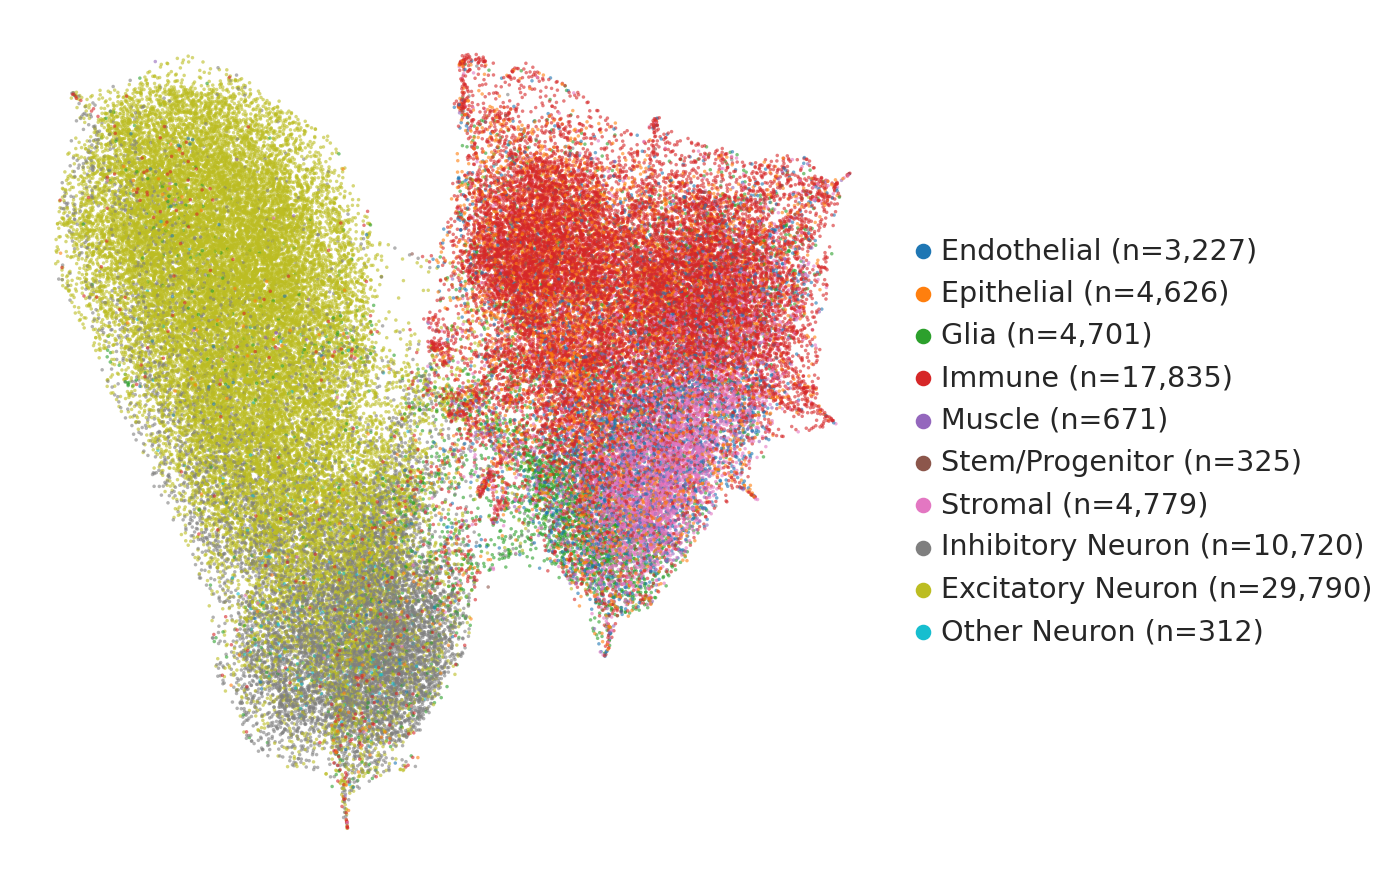

In [30]:
# 1. Compute neighbors (as you had it)
sc.pp.neighbors(human_adata, use_rep="X_leafletFA_K20")

# 2. Run UMAP (as you had it)
sc.tl.umap(human_adata)

# --- NEW STEPS FOR PUBLICATION QUALITY ---

# A. Create labels with counts for the legend
# We create a new column so we don't overwrite the original 'broad_cell_type' data
counts = human_adata.obs['broad_cell_type'].value_counts()
human_adata.obs['broad_cell_type_with_counts'] = human_adata.obs['broad_cell_type'].map(
    lambda x: f"{x} (n={counts[x]:,})" # Adds comma separator for thousands
)

# B. Plotting with adjustments
# 'tab10' or 'tab20' are matplotlib palettes that are generally quite distinct.
sc.pl.umap(
    human_adata,
    color="broad_cell_type_with_counts", # Use the new labels
    frameon=False,
    title="",                            # Usually better to remove title for papers and use figure captions
    alpha=0.6,                           # 0.0 to 1.0 - Lower this to see density better
    size=10,                             # Adjust dot size (try smaller if you have >50k cells)
    palette="tab10",                     # High contrast palette
    legend_loc="right margin",           # Keeps legend off the data
    show=False                           # Keep False so we can save/tweak below
)

# C. Save as high-res or vector
# Vector (PDF/SVG) is best for papers so text remains editable, 
# but if the file is too heavy, use high DPI PNG.
plt.savefig("umap_broad_cell_type.pdf", bbox_inches='tight') 
# OR
# plt.savefig("umap_broad_cell_type.png", dpi=300, bbox_inches='tight')

plt.show()

In [31]:
# Save the UMAP plot
plt.savefig(f"{output_dir}/umap_broad_cell_type.pdf")
print(f"Saved to {output_dir}/umap_broad_cell_type.pdf")

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/umap_broad_cell_type.pdf


<Figure size 560x560 with 0 Axes>

In [32]:
output_dir

'/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning'

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/aging_score_by_broad_cell_type.pdf


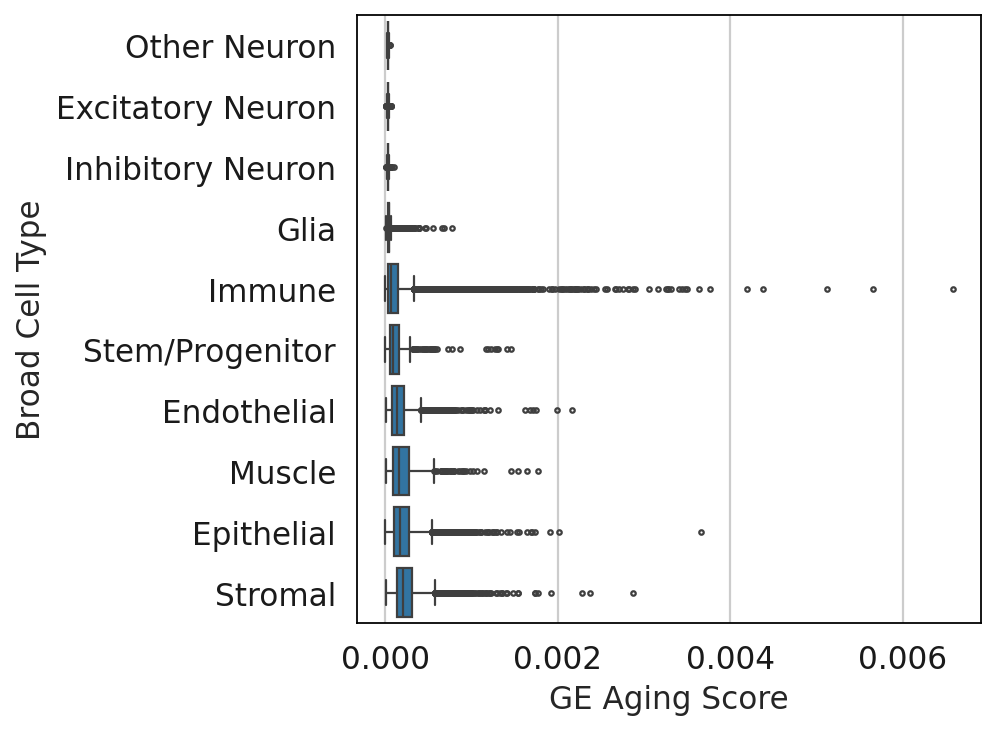

In [33]:
# make plot taller 
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(
    x="aging_score",
    y="broad_cell_type",
    data=ge_adata_subset.obs,
    order=order,
    fliersize=2  # Make outlier dots smaller
)
# make xaxs label "aging score"
ax.set_xlabel("GE Aging Score")
ax.set_ylabel("Broad Cell Type")
# save as pdf in output_dir
plt.savefig(f"{output_dir}/aging_score_by_broad_cell_type.pdf")
print(f"Saved to {output_dir}/aging_score_by_broad_cell_type.pdf")

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/aging_score_by_age.pdf


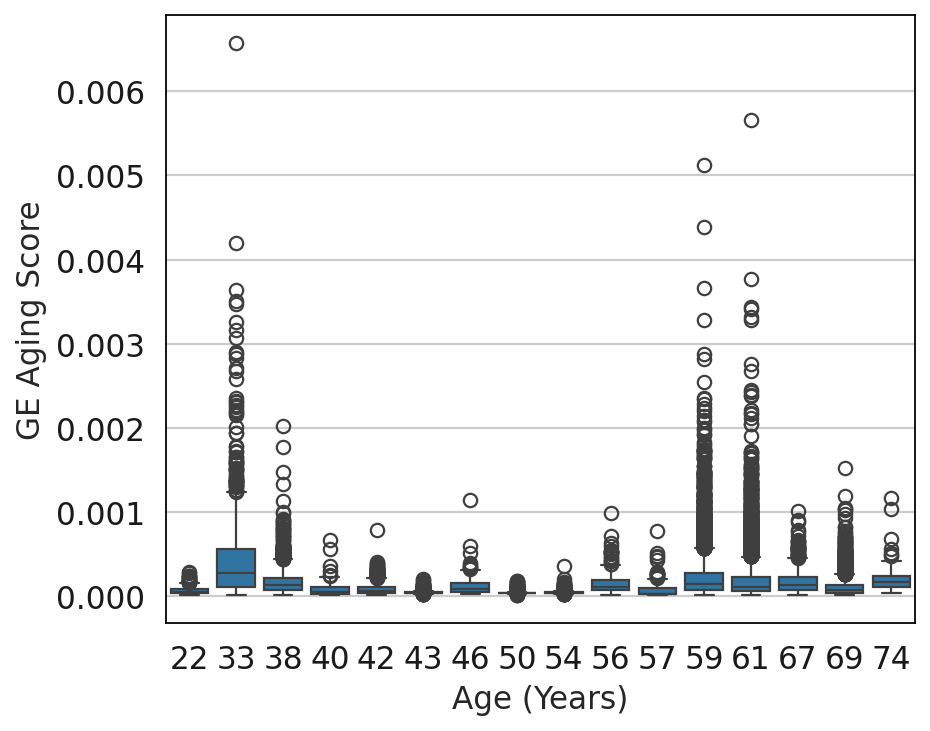

In [34]:
# plot aging_score across age groups
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x="age", y="aging_score", data=ge_adata_subset.obs, ax=ax)
# set x-axis and y-axis labels
ax.set_xlabel("Age (Years)")
ax.set_ylabel("GE Aging Score")
# save as pdf in output_dir
plt.savefig(f"{output_dir}/aging_score_by_age.pdf")
print(f"Saved to {output_dir}/aging_score_by_age.pdf")


In [35]:
human_adata

AnnData object with n_obs × n_vars = 76986 × 13510
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'cell_id_index', 'cell_id_clean', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'cell_type_str', 'tissue_str', 'cell_type_map', 'tissue_map', 'tissue_aligned', 'broad_cell_type', 'tissue_celltype_aligned', 'aging_score', 'broad_cell_type_with_counts'
    var: 'level_0', 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'clean_gene_id', 'gene_name', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'n_cells_detected', 'confidence', 'aging_ge

In [36]:
from scipy.stats import spearmanr

# Collect all SP_ columns
sp_cols = [col for col in human_adata.obs.columns if col.startswith("SP_")]

# -- 1. Global correlation (all cells) --
global_corrs = []
for col in sp_cols:
    rho, pval = spearmanr(human_adata.obs[col], human_adata.obs["aging_score"], nan_policy='omit')
    global_corrs.append({"SP": col, "spearman_r": rho, "p-value": pval})

global_corrs_df = pd.DataFrame(global_corrs)
print("Global SP/aging_score correlations:")
print(global_corrs_df.sort_values("spearman_r", ascending=False))

Global SP/aging_score correlations:
       SP  spearman_r        p-value
0    SP_1    0.549340   0.000000e+00
3    SP_4    0.370567   0.000000e+00
1    SP_2    0.358390   0.000000e+00
12  SP_13    0.126585  2.097636e-272
13  SP_14    0.112760  3.092507e-216
14  SP_15    0.045628   9.073069e-37
17  SP_18    0.029778   1.409938e-16
18  SP_19   -0.007498   3.749220e-02
15  SP_16   -0.072914   3.047163e-91
19  SP_20   -0.170821   0.000000e+00
16  SP_17   -0.173126   0.000000e+00
10  SP_11   -0.173471   0.000000e+00
11  SP_12   -0.245380   0.000000e+00
9   SP_10   -0.271630   0.000000e+00
7    SP_8   -0.283862   0.000000e+00
5    SP_6   -0.329078   0.000000e+00
6    SP_7   -0.337650   0.000000e+00
8    SP_9   -0.358930   0.000000e+00
2    SP_3   -0.482839   0.000000e+00
4    SP_5   -0.557268   0.000000e+00


In [37]:
# -- 2. By medium_cell_type group --
group_corrs = []
if "broad_cell_type" in human_adata.obs.columns:
    for group, subset in human_adata.obs.groupby("broad_cell_type"):
        for col in sp_cols:
            # Only analyze if group has enough cells
            if subset.shape[0] > 10:
                rho, pval = spearmanr(subset[col], subset["aging_score"], nan_policy='omit')
                group_corrs.append({
                    "broad_cell_type": group,
                    "SP": col,
                    "spearman_r": rho,
                    "p-value": pval,
                    "n_cells": subset.shape[0],
                })
    group_corrs_df = pd.DataFrame(group_corrs)
    group_corrs_df.sort_values("spearman_r", ascending=False)
else:
    print("broad_cell_type column not found in human_adata.obs.")

In [38]:
group_corrs_df.sort_values("spearman_r", ascending=False)

,broad_cell_type,SP,spearman_r,p-value,n_cells
141,Inhibitory Neuron,SP_2,0.392014,0.000000e+00,10720
181,Other Neuron,SP_2,0.332861,1.653158e-09,312
140,Inhibitory Neuron,SP_1,0.331444,3.357287e-273,10720
192,Other Neuron,SP_13,0.309984,2.247783e-08,312
152,Inhibitory Neuron,SP_13,0.303541,2.725814e-227,10720
...,...,...,...,...,...
84,Muscle,SP_5,-0.225211,3.660420e-09,671
164,Excitatory Neuron,SP_5,-0.234752,0.000000e+00,29790
151,Inhibitory Neuron,SP_12,-0.240209,1.530282e-140,10720
61,Immune,SP_2,-0.241910,7.532540e-236,17835


In [39]:
# -- 2. By medium_cell_type group --
group_corrs = []
if "tissue_celltype_aligned" in human_adata.obs.columns:
    for group, subset in human_adata.obs.groupby("tissue_celltype_aligned"):
        for col in sp_cols:
            # Only analyze if group has enough cells
            if subset.shape[0] > 10:
                rho, pval = spearmanr(subset[col], subset["aging_score"], nan_policy='omit')
                group_corrs.append({
                    "tissue_celltype_aligned": group,
                    "SP": col,
                    "spearman_r": rho,
                    "p-value": pval,
                    "n_cells": subset.shape[0],
                })
    group_corrs_df = pd.DataFrame(group_corrs)
    group_corrs_df.sort_values("spearman_r", ascending=False)
else:
    print("tissue_celltype_aligned column not found in human_adata.obs.")

In [40]:
group_corrs_df.sort_values("spearman_r", ascending=False)

,tissue_celltype_aligned,SP,spearman_r,p-value,n_cells
1550,Lung_B_Cell,SP_11,0.830753,0.000020,18
108,Bladder_LEC,SP_9,0.788312,0.000022,21
1749,Lymph_Node_Endothelial,SP_10,0.706294,0.010245,12
2472,Skin_Myeloid,SP_13,0.692308,0.012593,12
1493,Liver_Plasma,SP_14,0.682147,0.001817,18
...,...,...,...,...,...
2666,Small_Intestine_Myeloid,SP_7,-0.709890,0.004451,14
1147,Large_Intestine_Myeloid,SP_8,-0.730769,0.004548,13
3312,Trachea_SmoothMus,SP_13,-0.736364,0.009760,11
3572,Vasculature_NK,SP_13,-0.738596,0.000304,19


In [41]:
group_corrs_df[group_corrs_df["SP"] == "SP_3"].sort_values("spearman_r", ascending=False)

,tissue_celltype_aligned,SP,spearman_r,p-value,n_cells
22,Bladder_B_Cell,SP_3,0.483623,0.004353,33
1362,Limb_Muscle_SmoothMus,SP_3,0.363636,0.245265,12
3522,Vasculature_Immune,SP_3,0.278261,0.187971,24
1802,Lymph_Node_NK,SP_3,0.272346,0.046334,54
342,Brain_Ex-Ctx,SP_3,0.271436,0.000000,29790
...,...,...,...,...,...
622,Eye_Microglia,SP_3,-0.489869,0.001335,40
2442,Skin_Muscle,SP_3,-0.500000,0.081864,13
2982,Thymus_Muscle,SP_3,-0.600000,0.006612,19
862,Heart_APC,SP_3,-0.606459,0.000624,28


In [42]:
group_corrs_df[group_corrs_df["SP"] == "SP_4"].sort_values("spearman_r", ascending=False)

,tissue_celltype_aligned,SP,spearman_r,p-value,n_cells
3023,Thymus_Plasma,SP_4,0.606029,2.272938e-07,61
183,Bladder_T_Cell,SP_4,0.605255,7.104333e-28,265
1663,Lung_Plasma,SP_4,0.600000,5.100326e-02,11
1503,Liver_T_Cell,SP_4,0.545924,1.909273e-02,18
3623,Vasculature_SmoothMus,SP_4,0.479836,1.989297e-09,140
...,...,...,...,...,...
1043,Large_Intestine_Endothelial,SP_4,-0.301991,3.623165e-03,91
2323,Skin_B_Cell,SP_4,-0.379121,2.014061e-01,13
3163,Trachea_APC,SP_4,-0.392157,1.194998e-01,17
803,Fat_Myeloid,SP_4,-0.418803,3.321616e-02,26


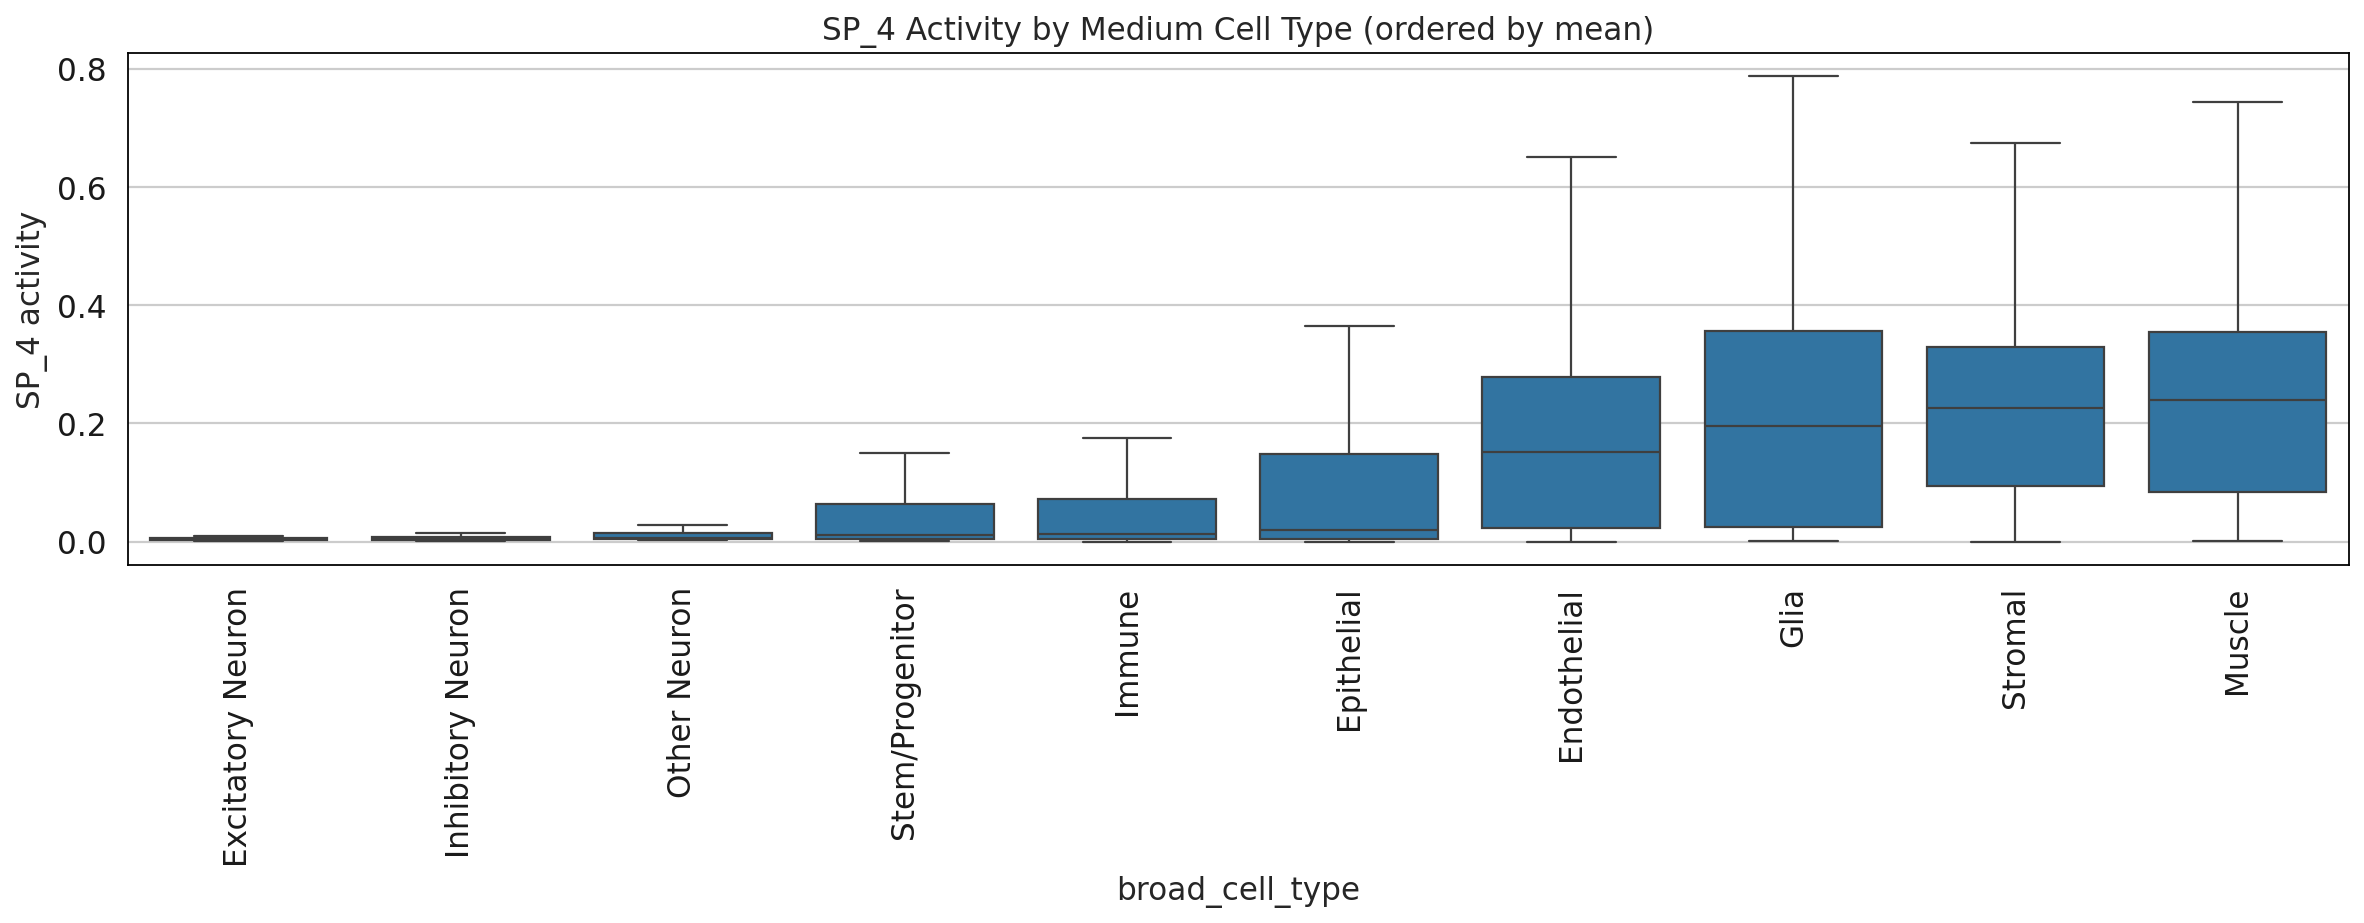

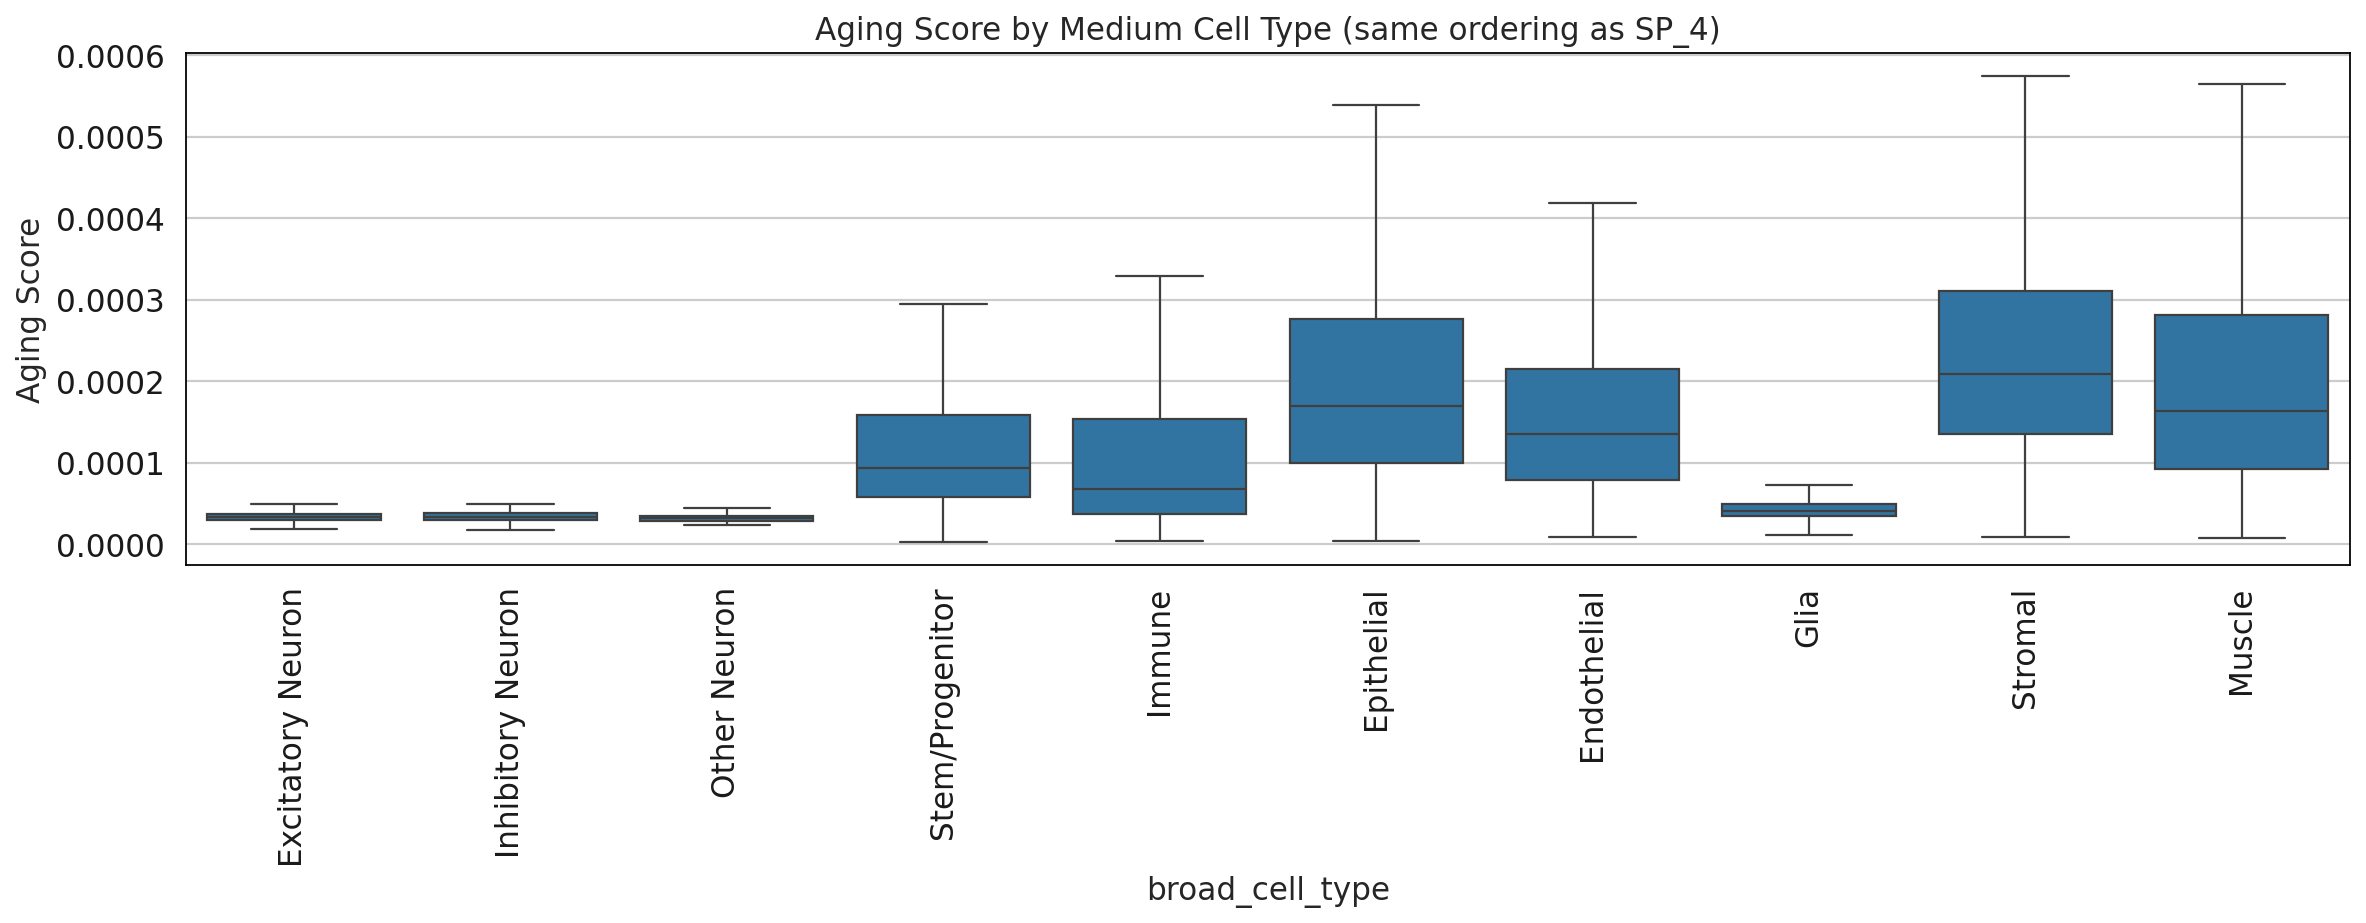

In [43]:
SP_plot = "SP_4"

# Check that medium_cell_type is present
if "broad_cell_type" in human_adata.obs.columns:
    # Prepare data and ordering by SP_3 as before
    data = human_adata.obs[["broad_cell_type", SP_plot, "aging_score"]].copy()
    mean_order = data.groupby("broad_cell_type")[SP_plot].mean().sort_values()
    ordered_types = mean_order.index.tolist()
    
    # First plot: SP_3
    plt.figure(figsize=(15, 6))
    sns.boxplot(
        data=data,
        x="broad_cell_type",
        y=SP_plot,
        order=ordered_types,
        showfliers=False
    )
    plt.xticks(rotation=90)
    plt.title(f"{SP_plot} Activity by Medium Cell Type (ordered by mean)")
    plt.xlabel("broad_cell_type")
    plt.ylabel(f"{SP_plot} activity")
    plt.tight_layout()
    plt.show()

    # Second plot: aging_score with same order
    plt.figure(figsize=(15, 6))
    sns.boxplot(
        data=data,
        x="broad_cell_type",
        y="aging_score",
        fill="lightgray",
        order=ordered_types,
        showfliers=False
    )
    plt.xticks(rotation=90)
    plt.title(f"Aging Score by Medium Cell Type (same ordering as {SP_plot})")
    plt.xlabel("broad_cell_type")
    plt.ylabel("Aging Score")
    plt.tight_layout()
    plt.show()
else:
    print("broad_cell_type column not found in human_adata.obs.")


In [44]:
# calculate median age group in each broad_cell_type
median_age = human_adata.obs.groupby("broad_cell_type")["age"].median().mean()
# add new age_group column to human_adata.obs
human_adata.obs["age_group"] = human_adata.obs["age"].apply(lambda x: "old" if x > median_age else "young")
human_adata.obs["age_group"].value_counts()

age_group
old      44268
young    32718
Name: count, dtype: int64

In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.patches import Circle, Rectangle

def plot_factor_circles(adata, cell_type_col='broad_cell_type', age_col='age_group'):
    """
    Clustered tile plot: background color shows delta PSI (old - young),
    circle outlines show activity (median nonzero expression).
    """
    # Extract factor matrix
    X_PHI = adata.obsm["X_leafletFA_K20"]
    n_factors = X_PHI.shape[1]
    factor_cols = [f"SP_{i+1}" for i in range(n_factors)]
    factor_df = pd.DataFrame(X_PHI, index=adata.obs.index, columns=factor_cols)

    # Median expression (non-zero) per cell type
    median_expr = pd.DataFrame(index=adata.obs[cell_type_col].unique(), columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        ct_data = factor_df.loc[ct_mask]
        for factor in factor_cols:
            vals = ct_data[factor]
            nonzero = vals[vals > 0]
            median_expr.loc[ct, factor] = nonzero.median() if len(nonzero) > 0 else 0
    median_expr = median_expr.astype(float).fillna(0)

    # Delta PSI: old - young
    delta_age = pd.DataFrame(index=median_expr.index, columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        old_mask = ct_mask & (adata.obs[age_col] == 'old')
        young_mask = ct_mask & (adata.obs[age_col] == 'young')
        if old_mask.sum() > 10 and young_mask.sum() > 10:
            for factor in factor_cols:
                old_vals = factor_df.loc[old_mask, factor]
                young_vals = factor_df.loc[young_mask, factor]
                delta_age.loc[ct, factor] = old_vals.median() - young_vals.median()
        else:
            delta_age.loc[ct] = 0
    delta_age = delta_age.astype(float).fillna(0)

    # Clustering
    factor_order = list(range(len(factor_cols)))  # preserve original SP_1 ... SP_K order
    celltype_order = dendrogram(linkage(median_expr, method='ward'), no_plot=True)['leaves']
    celltype_order = [median_expr.index[i] for i in celltype_order]

    # Compute cell counts
    celltype_counts = adata.obs[cell_type_col].value_counts()
    celltype_labels = [f"{ct} ({celltype_counts[ct]})" for ct in celltype_order]

    # Reorder matrices
    median_ordered = median_expr.loc[celltype_order, :].iloc[:, factor_order]
    delta_ordered = delta_age.loc[celltype_order, :].iloc[:, factor_order]

    # Plot setup
    fig, ax = plt.subplots(figsize=(10, 7))
    n_cells = len(median_ordered)
    n_factors = len(median_ordered.columns)
    ax.set_xlim(-0.5, n_factors - 0.5)
    ax.set_ylim(-0.5, n_cells - 0.5)

    # Color scale for delta PSI
    cmap = plt.cm.BrBG
    vmax = max(abs(delta_ordered.values.min()), abs(delta_ordered.values.max()))
    norm = plt.Normalize(vmin=-vmax, vmax=vmax)

    # Draw tiles
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            delta = delta_ordered.loc[cell_type, factor]
            color = cmap(norm(delta))
            tile = Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='none')
            ax.add_patch(tile)

    # Draw circle outlines for activity
    min_radius = 0.1
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            expr = median_ordered.loc[cell_type, factor]
            if expr > 0.001:
                radius = max(min_radius, (np.log10(expr + 0.01) + 2) * 0.15)
                delta = delta_ordered.loc[cell_type, factor]
                color = cmap(norm(delta))  # match background
                circle = Circle((j, i), radius, facecolor=color, edgecolor='black', linewidth=0.4)
                ax.add_patch(circle)

    # Axis labels
    ax.set_xticks(range(n_factors))
    ax.set_xticklabels(median_ordered.columns, rotation=90, fontsize=10)
    ax.set_yticks(range(n_cells))
    ax.set_yticklabels(celltype_labels, fontsize=10)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False)
    ax.grid(False)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Δ SP Activity (old - young)', shrink=0.3)

    from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox, VPacker, HPacker, TextArea

    # Legend values (representative activity levels)
    example_exprs = [0.01, 0.1, 1.0]

    # Function to compute radius in axis units
    def compute_radius(val):
        return max(min_radius, (np.log10(val + 0.01) + 2) * 0.15)

    # Build legend items
    legend_items = []
    for val in example_exprs:
        radius = compute_radius(val)

        # Circle scaled correctly in data units
        circle_box = AuxTransformBox(ax.transData)
        circle = Circle((0, 0), radius, facecolor='white', edgecolor='black', linewidth=0.6)
        circle_box.add_artist(circle)

        # Label
        label = TextArea(f"{val:.2f}", textprops=dict(fontsize=8, va='center', ha='left'))

        # Combine horizontally: [circle | label]
        item = HPacker(children=[circle_box, label], align="center", pad=0, sep=5)
        legend_items.append(item)

    # Combine all items vertically
    legend_box = VPacker(children=legend_items, align="left", pad=0, sep=6)

    # Place the anchored box
    anchored_legend = AnchoredOffsetbox(
        loc='upper right',
        child=legend_box,
        frameon=True,
        bbox_to_anchor=(1.25, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=0.5,
        pad=0.5
    )
    ax.add_artist(anchored_legend)

    plt.tight_layout()
    return fig

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/delta_median_old_minus_young_by_broad_cell_type_dot_heatmap.pdf


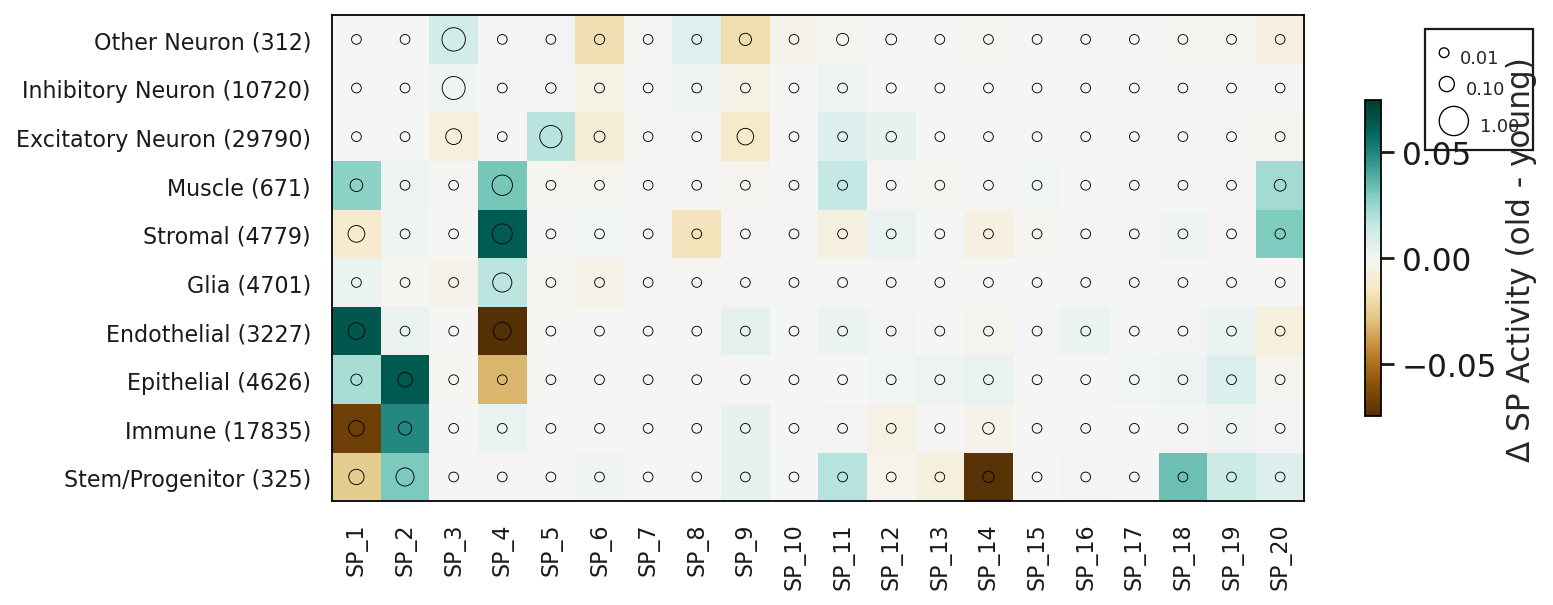

In [46]:
cell_type_col = "broad_cell_type"
fig = plot_factor_circles(human_adata, cell_type_col=cell_type_col)

plt.savefig(f"{output_dir}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {output_dir}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

In [47]:
cell_type_col = "tissue_celltype_aligned"
# get top 50 most common cell types 
top_50_cell_types = human_adata.obs["tissue_celltype_aligned"].value_counts().index[:30].tolist()

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/delta_median_old_minus_young_by_tissue_celltype_aligned_dot_heatmap.pdf


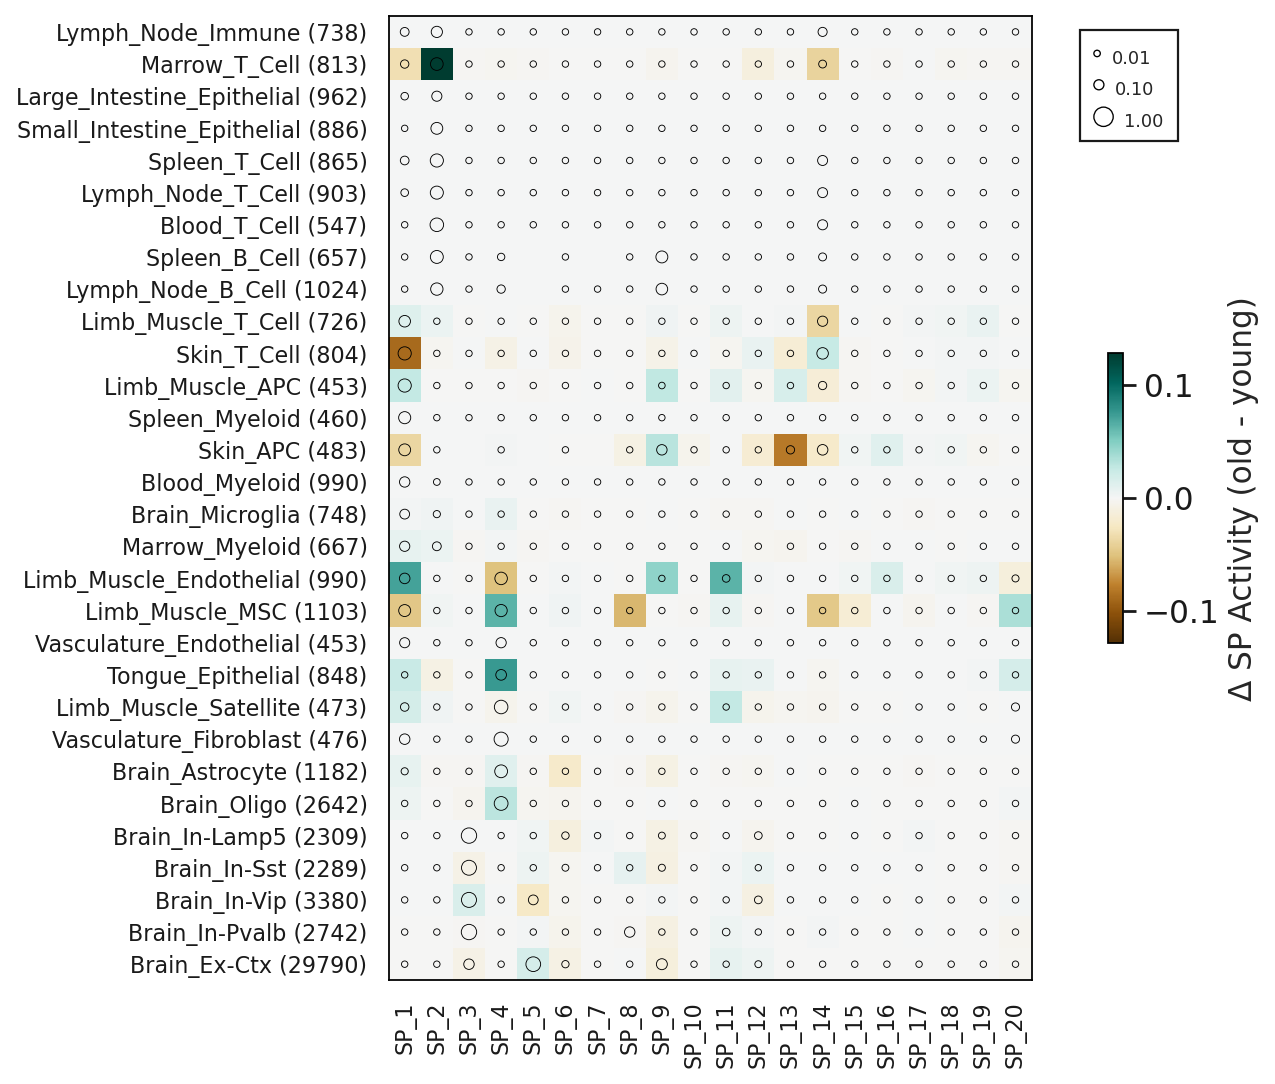

In [48]:
fig = plot_factor_circles(human_adata[human_adata.obs["tissue_celltype_aligned"].isin(top_50_cell_types)], cell_type_col=cell_type_col)

plt.savefig(f"{output_dir}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {output_dir}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

In [49]:
# Get perplexity of human_adata
PHI = human_adata.obsm["X_leafletFA_K20"]
# Calculate cell perplexity/entropy 
print("Calculating cell perplexity...")
PHI_safe = np.clip(PHI, 1e-10, 1)  # Prevent log(0) errors
entropy = -np.sum(PHI_safe * np.log(PHI_safe), axis=1)
perplexity = np.exp(entropy)
human_adata.obs["perplexity"] = perplexity
# Calculate median perplexity value across all cells 
median_perplexity = human_adata.obs["perplexity"].median()
print(f"Median perplexity value across all cells: {median_perplexity}")

Calculating cell perplexity...
Median perplexity value across all cells: 6.9922943115234375


Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/perplexity_by_sex_rasterized.pdf


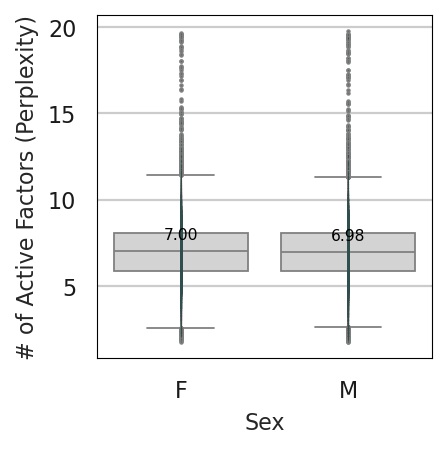

In [50]:
plt.figure(figsize=(3, 3))

# Boxplot: keep as vector
sns.boxplot(
    data=human_adata.obs,
    x="sex", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot: will rasterize below
stripplot = sns.stripplot(
    data=human_adata.obs,
    x="sex", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    human_adata.obs
    .groupby("sex", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Sex", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{output_dir}/perplexity_by_sex_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

Saved corrected plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/perplexity_by_cell_type_ordered_rasterized.pdf


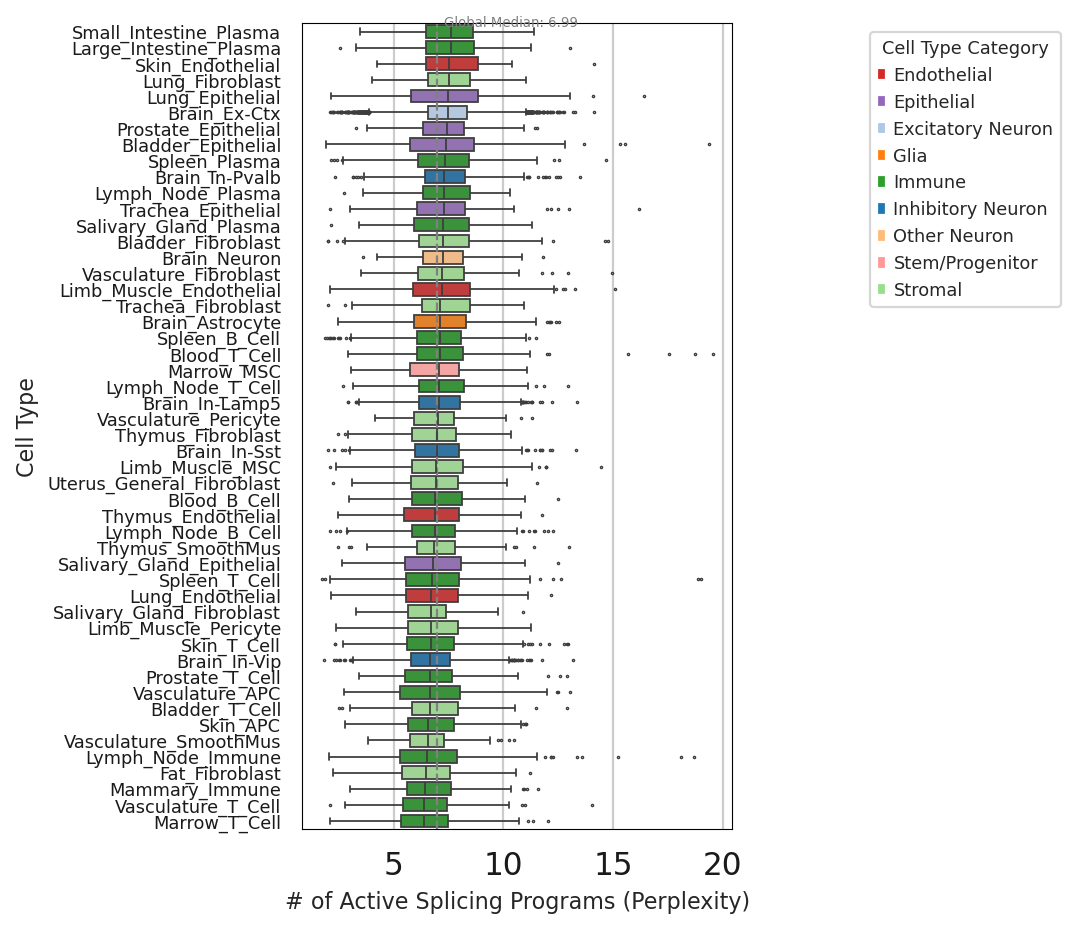

In [51]:
# --- The Complete, Corrected Plotting Script ---

## 🛠️ Step 1: Data Preparation

# Only consider tissue_celltype groups with >= 100 cells for plotting
celltype_counts = human_adata.obs["tissue_celltype_aligned"].value_counts()
valid_celltypes = celltype_counts[celltype_counts >= 100].index
plot_obs = human_adata.obs[human_adata.obs["tissue_celltype_aligned"].isin(valid_celltypes)].copy()

# Compute median perplexity by tissue_celltype and get top 20
median_order = (
    plot_obs
    .groupby("tissue_celltype_aligned", observed=True)["perplexity"]
    .median()
    .sort_values(ascending=False)
    .head(50)
    .index
)

# Color palette for broad_cell_type
unique_broad = plot_obs["broad_cell_type"].unique()
palette = sns.color_palette("tab20", len(unique_broad))
palette_dict = dict(zip(unique_broad, palette))

# Map the tissue_celltype to its broad_cell_type color
color_map = plot_obs.set_index("tissue_celltype_aligned")["broad_cell_type"].to_dict()

# Create a list of colors in the exact order of the boxplots (median_order)
plot_colors = [palette_dict[color_map[cell_type]] for cell_type in median_order]


## 📊 Step 2: Main Plotting

# Start figure
fig, ax = plt.subplots(figsize=(8, 6))

# Main plot - REMOVE 'hue' and use 'plot_colors' to center the boxplots
bp = sns.boxplot(
    data=plot_obs,
    y="tissue_celltype_aligned", 
    x="perplexity", 
    fliersize=0.6, 
    linewidth=0.8,
    order=median_order,
    palette=plot_colors, # Use the pre-calculated list of colors
    ax=ax
)

# Rasterize fliers (optional, for PDF size optimization)
for c in ax.collections:
    if isinstance(c, plt.collections.PathCollection):
        c.set_rasterized(True)

# Global median line
global_median = human_adata.obs["perplexity"].median()
ax.axvline(global_median, color='gray', linestyle='--', linewidth=1)
ax.text(global_median + 0.3, -1, f"Global Median: {global_median:.2f}",
        color='gray', fontsize=6, va='top')


## 🎨 Step 3: Legend and Formatting

# Manually create the legend since 'hue' was removed
# 1. Get unique broad cell types present in the top 20
broad_types_in_plot = sorted(list(set(color_map[cell] for cell in median_order)))

# 2. Create legend handles and labels
handles = [plt.Rectangle((0, 0), 1, 1, fc=palette_dict[bt]) for bt in broad_types_in_plot]
labels = broad_types_in_plot

ax.legend(
    handles=handles,
    labels=labels,
    title="Cell Type Category",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=8,
    frameon=True
)

# Axis formatting
ax.set_ylabel("Cell Type", fontsize=10)
ax.set_xlabel("# of Active Splicing Programs (Perplexity)", fontsize=10)
ax.tick_params(axis='y', labelsize=8)

# Border
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Save
plt.tight_layout()
pdf_path = f"{output_dir}/perplexity_by_cell_type_ordered_rasterized.pdf"
plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
print(f"Saved corrected plot to: {pdf_path}")
plt.show()

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/perplexity_by_broad_cell_type.pdf


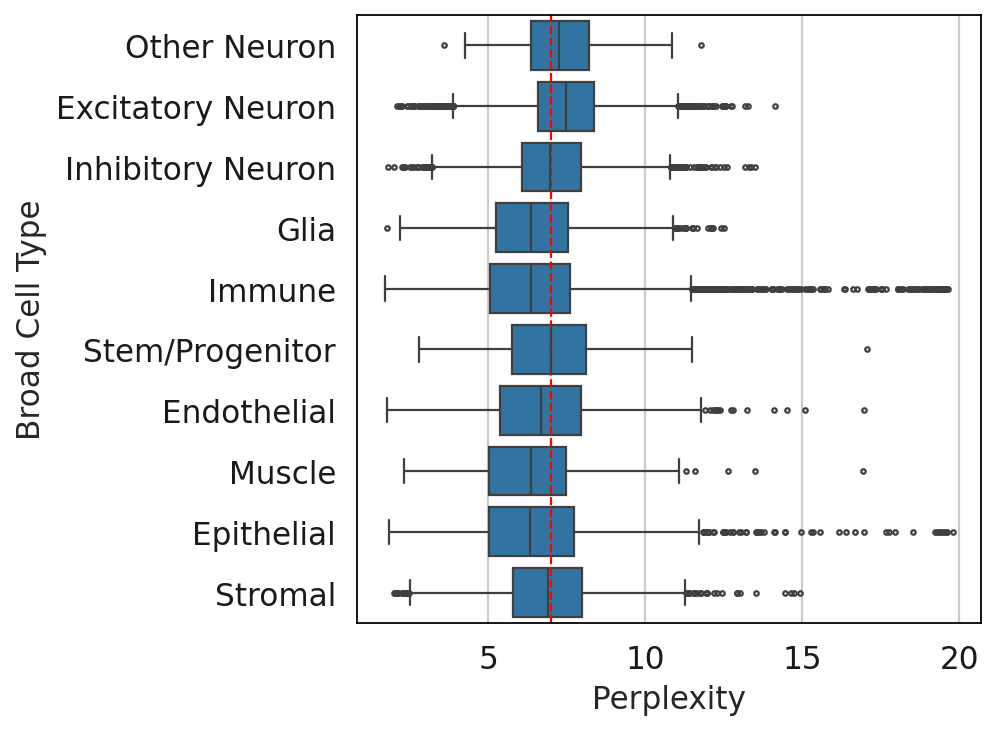

In [52]:
# make plot taller 
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(
    x="perplexity",
    y="broad_cell_type",
    data=human_adata.obs,
    order=order,
    fliersize=2  # Make outlier dots smaller
)
# Add vertical dashed red line at the overall median perplexity value
median_perplexity = human_adata.obs["perplexity"].median()
ax.axvline(median_perplexity, color="red", linestyle="--", linewidth=1, label="Median")

# x axis label/formatting
ax.set_xlabel("Perplexity")
ax.set_ylabel("Broad Cell Type")
# save as pdf in output_dir
plt.savefig(f"{output_dir}/perplexity_by_broad_cell_type.pdf")
print(f"Saved to {output_dir}/perplexity_by_broad_cell_type.pdf")

In [53]:
# Mouse based RBP markers 
sj_markers = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE3/figures/final_df.tsv.gz"
sj_markers_df = pd.read_csv(sj_markers, sep="\t")
# remove gene_name_y and rename gene_name_x to gene_name
sj_markers_df = sj_markers_df.drop(columns=["gene_name_y"])
sj_markers_df = sj_markers_df.rename(columns={"gene_name_x": "gene_name"})
sj_markers_df.head()
markers = sj_markers_df[["junction_id", "gene_name", "effect_size", "abs_effect_size", "junction_idx", "factor_idx"]].sort_values(by="abs_effect_size", ascending=False)

In [54]:
# Load mouse aging analysis 
feature_importance_df_file="/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/feature_importance_df.csv"
# Read in the splicing and gene expression aging feature importance results
feature_importance_df = pd.read_csv(feature_importance_df_file)
feature_importance_df = feature_importance_df[feature_importance_df["factor_name"].isin(["SP_1", "SP_2", "SP_4"])]
print(feature_importance_df["cell_type"].nunique())
print(feature_importance_df.head())

76
             cell_type factor_type factor_name  coefficient  abs_coefficient  \
0   Trachea_Epithelial    Splicing        SP_1     0.549265         0.549265   
1   Trachea_Epithelial    Splicing        SP_2    -0.423479         0.423479   
3   Trachea_Epithelial    Splicing        SP_4    -0.244587         0.244587   
40   Skin_Keratinocyte    Splicing        SP_1     0.299427         0.299427   
41   Skin_Keratinocyte    Splicing        SP_2     0.449305         0.449305   

    combined_r2     p_vs_scvi  
0      0.396454  6.948340e-01  
1      0.396454  6.948340e-01  
3      0.396454  6.948340e-01  
40     0.637374  1.110223e-16  
41     0.637374  1.110223e-16  


In [55]:
feature_importance_df[feature_importance_df["cell_type"] == "Heart_Endothelial"]
# Find a comperable cell type with an aging signal 

,cell_type,factor_type,factor_name,coefficient,abs_coefficient,combined_r2,p_vs_scvi
680,Heart_Endothelial,Splicing,SP_1,0.255910,0.255910,0.530556,0.213497
681,Heart_Endothelial,Splicing,SP_2,0.368099,0.368099,0.530556,0.213497
683,Heart_Endothelial,Splicing,SP_4,-0.443745,0.443745,0.530556,0.213497


In [56]:
human_adata[human_adata.obs["broad_cell_type"] == "Neuron"].obs["tissue_celltype_aligned"].value_counts()

Series([], Name: count, dtype: int64)

... storing 'age_group' as categorical


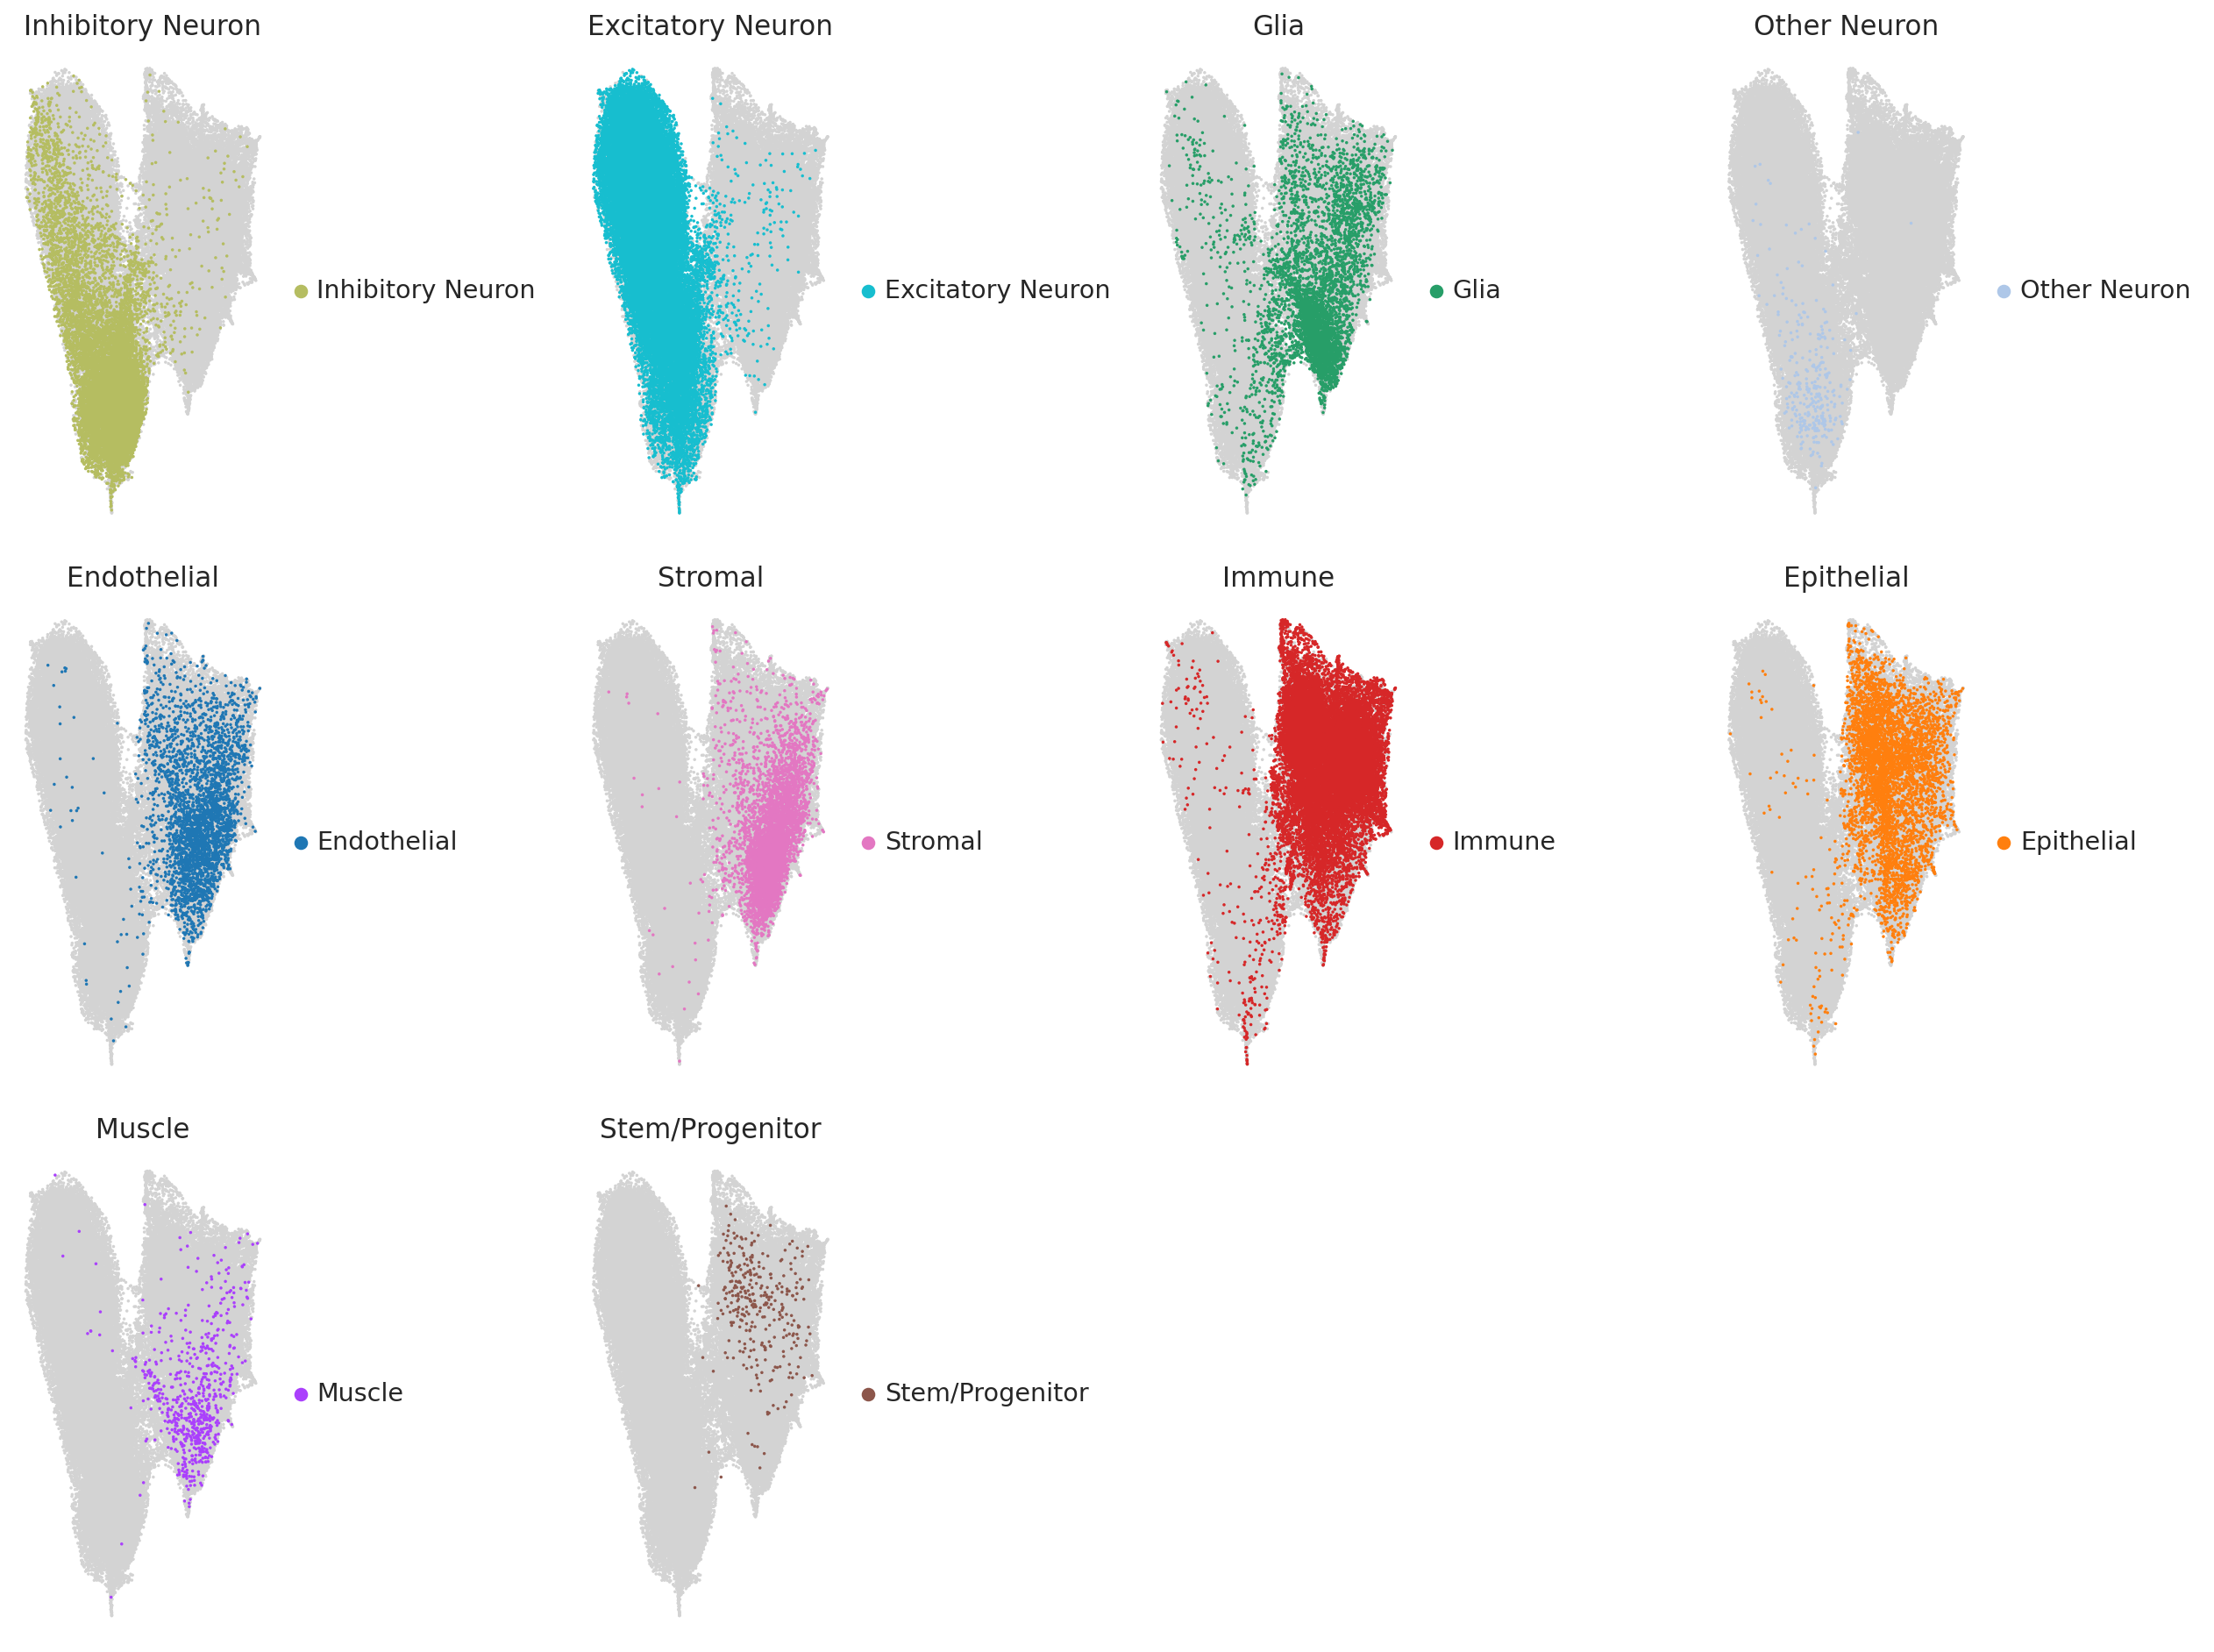

Combined plot displayed!


In [57]:
import math

# 1. Get the list of unique cell types and filter out 'nan' if present
cell_types = human_adata.obs['broad_cell_type'].dropna().unique().tolist()
num_plots = len(cell_types)

# 2. Determine the optimal grid size for the subplots
# For example, if num_plots=8, we use 2 rows and 4 columns.
# We choose a layout that is visually appealing (close to square)
cols = math.ceil(math.sqrt(num_plots * 1.5)) # Adjust factor for slightly wider layout
rows = math.ceil(num_plots / cols)

# 3. Create the main figure and subplots
# figsize is set dynamically based on the grid size
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

# Flatten the axes array for easy iteration, handling cases where rows/cols is 1
axes = axes.flatten()

# 4. Loop through each cell type and plot onto the corresponding subplot
for i, cell_type in enumerate(cell_types):
    ax = axes[i] # Get the current subplot axis

    # Scanpy plotting directly onto the subplot axis (ax=ax)
    sc.pl.umap(
        human_adata,
        color="broad_cell_type",
        groups=[cell_type],
        frameon=False,
        title=f"{cell_type}",  # Set title for the subplot
        size=10,
        show=False,           # Crucial: Prevent immediate display
        ax=ax,                # CRUCIAL: Plot directly onto the current subplot
        na_in_legend=False
    )
    
    # 5. RASTERIZATION (Apply to the current subplot's collections)
    for collection in ax.collections:
        collection.set_rasterized(True)

# 6. Hide any unused subplots (if num_plots < rows * cols)
for j in range(num_plots, rows * cols):
    fig.delaxes(axes[j])

# 7. Final Polish and Display/Save
plt.tight_layout() # Adjust spacing between subplots
plt.show()

print("Combined plot displayed!")

In [58]:
# Lets just focus on endothelial cells 
endothelial = human_adata[human_adata.obs["broad_cell_type"] == "Endothelial"]
endothelial

View of AnnData object with n_obs × n_vars = 3227 × 13510
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'cell_id_index', 'cell_id_clean', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'cell_type_str', 'tissue_str', 'cell_type_map', 'tissue_map', 'tissue_aligned', 'broad_cell_type', 'tissue_celltype_aligned', 'aging_score', 'broad_cell_type_with_counts', 'age_group', 'perplexity'
    var: 'level_0', 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'clean_gene_id', 'gene_name', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'n_cells_

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/clustermap_SP_1_SP_2_SP_4_by_tissue_celltype_aligned_endothelial_FLIPPED.pdf


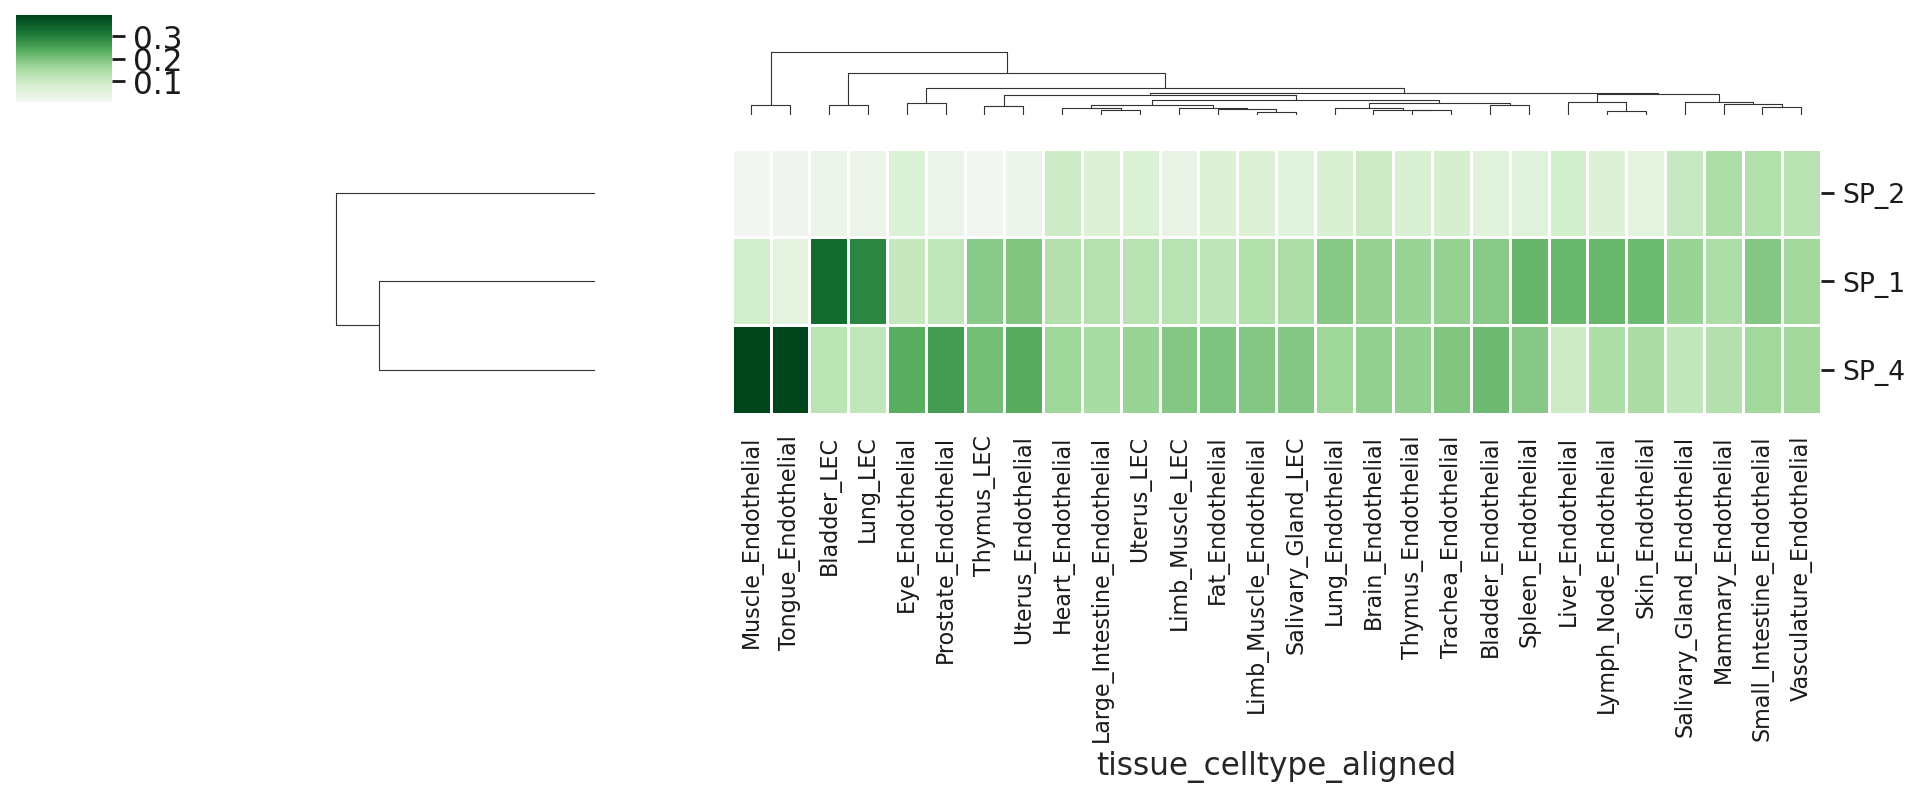

In [59]:
# Clustermap of SP_1, SP_2, SP_4 activity by tissue_celltype_aligned for endothelial cells
# Flip so that cell types are along the x-axis and SP factors are rows

# 1. Pull relevant columns for endothelial cells
endothelial_sp = endothelial.obs[["tissue_celltype_aligned", "SP_1", "SP_2", "SP_4"]].copy()

# 2. Group by tissue_celltype_aligned and take the mean for SP_1, SP_2, SP_4
cluster_data = (
    endothelial_sp
    .groupby("tissue_celltype_aligned")[["SP_1", "SP_2", "SP_4"]]
    .mean()
    .dropna()
)

# 3. Transpose so that tissue_celltype_aligned are columns, factors are rows
cluster_data_t = cluster_data.T

# 4. Plot clustermap with ALL column (cell type) labels on
g = sns.clustermap(
    cluster_data_t,
    cmap="PRGn",       # Purple-to-Green palette
    center=0,
    linewidths=0.5,
    figsize=(12, 3),   # wide plot, short height (since only 3 rows)
    xticklabels=True,
    yticklabels=True
)

# 5. Formatting the labels (cell types now on x-axis)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=10)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)

# Save to pdf in output_dir
plt.savefig(f"{output_dir}/clustermap_SP_1_SP_2_SP_4_by_tissue_celltype_aligned_endothelial_FLIPPED.pdf", bbox_inches="tight")
print(f"Saved to {output_dir}/clustermap_SP_1_SP_2_SP_4_by_tissue_celltype_aligned_endothelial_FLIPPED.pdf")
plt.show()

In [60]:
# Load atse_mapping, subset_splice_adata_mouse, subset_splice_adata_human from MODEL_FILES
atse_mapping = pd.read_csv(f"{MODEL_FILES}/atse_mapping.csv")
atse_mapping.head()

,human_junction_id,mouse_junction_id,mouse_gene,human_gene,human_event_id,mouse_event_id
0,chr12_88515617_88516333_-,chr10_100080130_100080856_+,ENSMUSG00000019966,ENSG00000049130,ENSG00000049130.16_atse_3,ENSMUSG00000019966.18_atse_2
1,chr12_88507137_88516333_-,chr10_100080130_100087346_+,ENSMUSG00000019966,ENSG00000049130,ENSG00000049130.16_atse_3,ENSMUSG00000019966.18_atse_2
2,chr12_88507137_88515533_-,chr10_100080940_100087346_+,ENSMUSG00000019966,ENSG00000049130,ENSG00000049130.16_atse_3,ENSMUSG00000019966.18_atse_2
3,chr12_88115570_88117032_-,chr10_100512399_100513560_+,ENSMUSG00000019971,ENSG00000198707,ENSG00000198707.17_atse_4,ENSMUSG00000019971.10_atse_2
4,chr12_88115182_88117032_-,chr10_100512399_100513919_+,ENSMUSG00000019971,ENSG00000198707,ENSG00000198707.17_atse_4,ENSMUSG00000019971.10_atse_2


In [61]:
conserved_sj_markers = sj_markers_df[sj_markers_df["junction_id"].isin(atse_mapping["mouse_junction_id"])]
# subset to just those in factor_idx 1 and 3 (correspnding to SP2 and SP4)
conserved_sj_markers = conserved_sj_markers[conserved_sj_markers["factor_idx"].isin([0, 3])]
# now subset to just the significant ones 
conserved_sj_markers = conserved_sj_markers[conserved_sj_markers["significant"]]
conserved_sj_markers.sort_values(by="abs_effect_size", ascending=False).head(10)

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
46642,0,46642,0.964622,0.964622,0.000058,100.0,1.0,0.0,True,0.25,...,0.2373,1.0000,507319,120400,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
239773,3,29467,0.952713,0.952713,0.000265,100.0,1.0,0.0,True,0.25,...,0.4681,0.4227,71563,79260,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
28161,0,28161,0.930707,0.930707,0.000493,100.0,1.0,0.0,True,0.25,...,0.2361,1.0000,34810,8220,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
44391,0,44391,0.924922,0.924922,0.000460,100.0,1.0,0.0,True,0.25,...,0.4091,1.0000,34042,13926,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
239786,3,29480,0.911522,0.911522,0.000240,100.0,1.0,0.0,True,0.25,...,0.3482,0.3558,71791,70246,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
32649,0,32649,0.909321,0.909321,0.000241,100.0,1.0,0.0,True,0.25,...,0.5560,1.0000,87931,48890,GT-AG,GT,AG,0.0,0.0,Both_SS_annotated
37730,0,37730,0.903600,0.903600,0.000168,100.0,1.0,0.0,True,0.25,...,0.6070,0.9923,194637,119062,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
29351,0,29351,0.899628,0.899628,0.000074,100.0,1.0,0.0,True,0.25,...,0.7950,1.0000,113256,90034,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
216842,3,6536,0.896733,0.896733,0.000119,100.0,1.0,0.0,True,0.25,...,0.3905,1.0000,181882,71020,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
216844,3,6538,0.889758,0.889758,0.000156,100.0,1.0,0.0,True,0.25,...,0.3680,1.0000,203379,74848,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated


In [62]:
conserved_sj_markers["junction_id"].nunique()

5710

In [63]:
atse_mapping = atse_mapping[atse_mapping["mouse_junction_id"].isin(conserved_sj_markers["junction_id"])]
atse_mapping["human_junction_id"].nunique()

5710

In [64]:
endothelial

View of AnnData object with n_obs × n_vars = 3227 × 13510
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'cell_id_index', 'cell_id_clean', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'cell_type_str', 'tissue_str', 'cell_type_map', 'tissue_map', 'tissue_aligned', 'broad_cell_type', 'tissue_celltype_aligned', 'aging_score', 'broad_cell_type_with_counts', 'age_group', 'perplexity'
    var: 'level_0', 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'clean_gene_id', 'gene_name', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'n_cells_

In [65]:
# reset endothelial.var_names 
endothelial.var_names = endothelial.var["junction_id"]
endothelial.var_names

Index(['chr12_88515617_88516333_-', 'chr12_88507137_88516333_-',
       'chr12_88507137_88515533_-', 'chr12_88115570_88117032_-',
       'chr12_88115182_88117032_-', 'chr12_88054413_88055575_-',
       'chr12_85805962_85836154_-', 'chr12_82687669_82857009_+',
       'chr12_81369194_81374633_-', 'chr12_81369194_81369621_-',
       ...
       'chrX_65524262_65524964_-', 'chrX_65524614_65524964_-',
       'chrX_68210282_68212107_-', 'chrX_68829904_68838616_+',
       'chrX_68831314_68838616_+', 'chrY_13360528_13366266_-',
       'chrY_13366393_13369255_-', 'chrY_13366393_13369260_-',
       'chrY_19716111_19716278_-', 'chrY_19716004_19716278_-'],
      dtype='object', name='junction_id', length=13510)

In [66]:
# Subset endothelial cells to just those junctions in atse_mapping["human_junction_id"]
# IMPORTANT: We must use `.var_names` (column index), so first get a list of human_junction_ids that exist in var_names

# 1. Get the list of query junction ids
matching_junctions = atse_mapping["human_junction_id"].values

# 2. Find which of these matching_junctions are *actually present* as var_names (AnnData expects var_names for .loc)
present_junctions = [j for j in matching_junctions if j in endothelial.var_names]

if len(present_junctions) == 0:
    raise ValueError("No matching human_junction_id found in endothelial.var_names")

# 3. Subset by var_names (strings)
endothelial_sj = endothelial[:, present_junctions]
endothelial_sj

View of AnnData object with n_obs × n_vars = 3227 × 5710
    obs: 'cell_id', 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'cell_id_index', 'cell_id_clean', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'cell_type_str', 'tissue_str', 'cell_type_map', 'tissue_map', 'tissue_aligned', 'broad_cell_type', 'tissue_celltype_aligned', 'aging_score', 'broad_cell_type_with_counts', 'age_group', 'perplexity'
    var: 'level_0', 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'clean_gene_id', 'gene_name', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'n_cells_d

In [67]:
endothelial_sj.layers["denoised_PSI"] = endothelial_sj.obsm["X_leafletFA_K20"] @ endothelial_sj.varm["psi_learned"].T

In [68]:
import pandas as pd
from scipy.stats import spearmanr

# Create a DataFrame for the denoised PSI values:
psi_df = pd.DataFrame(
    endothelial_sj.layers["denoised_PSI"],
    index=endothelial_sj.obs_names,
    columns=endothelial_sj.var_names
)

# Get the ages (matching order of obs_names)
ages = endothelial_sj.obs["age"].astype(float)

# Store correlations
correlations = []
for junc in psi_df.columns:
    psi_values = psi_df[junc].values
    mask = ~pd.isnull(psi_values) & ~pd.isnull(ages.values)
    if mask.sum() < 3:  # Require at least a few points to correlate
        corr, pval = (None, None)
    else:
        corr, pval = spearmanr(psi_values[mask], ages.values[mask])
    correlations.append({"junction_id": junc, "spearman_r": corr, "p_value": pval})

correlation_df = pd.DataFrame(correlations)
correlation_df


,junction_id,spearman_r,p_value
0,chr12_88115182_88117032_-,0.006541,7.103027e-01
1,chr12_88054413_88055575_-,0.081656,3.408325e-06
2,chr12_85805962_85836154_-,0.083532,2.017483e-06
3,chr12_82687669_82857009_+,0.034848,4.776588e-02
4,chr12_81369194_81374633_-,0.080789,4.325951e-06
...,...,...,...
5705,chrX_24619084_24646988_-,0.099215,1.624894e-08
5706,chrX_68210282_68212107_-,0.060023,6.462159e-04
5707,chrY_13360528_13366266_-,0.083962,1.786381e-06
5708,chrY_13366393_13369255_-,0.098068,2.374927e-08


Junction count breakdown by significance category:
  sig_coef  count
0       ns   2899
1      pos   2669
2      neg    142

Total number of significant (FDR < 0.05 and |rho| > 0.05) hits: 2811


### Junction count breakdown by significance category

,sig_coef,count
0,ns,2899
1,pos,2669
2,neg,142


**Total number of significant (FDR < 0.05 and |rho| > 0.05) hits: 2811**

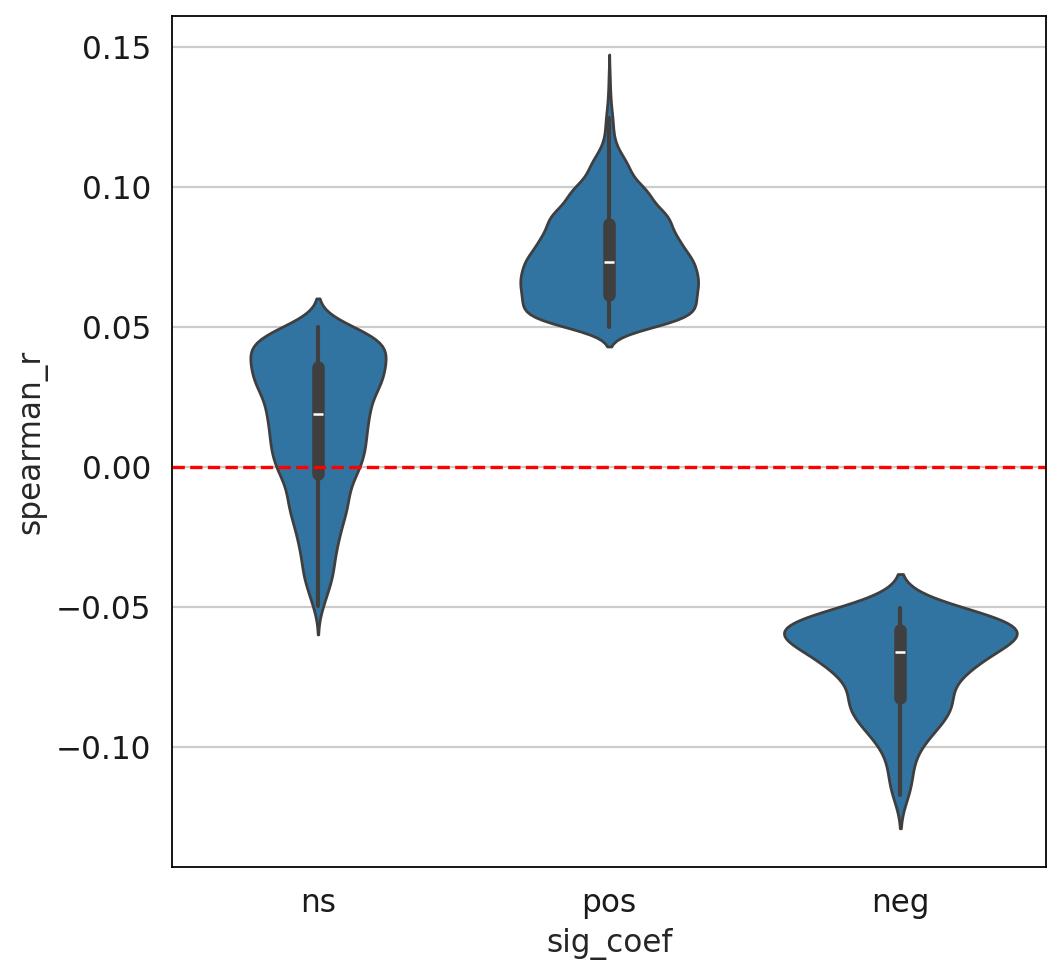

In [69]:
# summarize how many are significant at FDR < 0.05
import statsmodels.stats.multitest as smm

# add multiple testing correction to the p-values
correlation_df["fdr"] = smm.multipletests(correlation_df["p_value"], method="fdr_bh")[1]

# assign significance category only to those with significant FDR, else "ns"
def assign_sig_coef(row):
    if row["fdr"] >= 0.05 or pd.isnull(row["spearman_r"]):
        return "ns"
    elif row["spearman_r"] > 0.05:
        return "pos"
    elif row["spearman_r"] < -0.05:
        return "neg"
    else:
        return "ns"

correlation_df["sig_coef"] = correlation_df.apply(assign_sig_coef, axis=1)

# summary breakdown of junctions in each category
summary_counts = correlation_df["sig_coef"].value_counts().rename_axis('sig_coef').reset_index(name='count')
print("Junction count breakdown by significance category:")
print(summary_counts)

# Add: report the total number of significant hits (positive and negative)
n_sig = (correlation_df["sig_coef"].isin(["pos", "neg"])).sum()
print(f"\nTotal number of significant (FDR < 0.05 and |rho| > 0.05) hits: {n_sig}")

# Optionally, also display as markdown if in Jupyter notebook
try:
    from IPython.display import display, Markdown
    display(Markdown("### Junction count breakdown by significance category"))
    display(summary_counts)
    display(Markdown(f"**Total number of significant (FDR < 0.05 and |rho| > 0.05) hits: {n_sig}**"))
except ImportError:
    pass

# make violin plot of correlation_df["spearman_r"] by correlation_df["sig_coef"]
sns.violinplot(x="sig_coef", y="spearman_r", data=correlation_df)

# add dashed red line at 0
plt.axhline(0, color="red", linestyle="--")


In [70]:
correlation_df[correlation_df["junction_id"] == "chr18_35005553_35070194_+"]

,junction_id,spearman_r,p_value,fdr,sig_coef
2117,chr18_35005553_35070194_+,-0.117155,2.461762e-11,3.799098e-09,neg


In [71]:
candidate="chr18_35005553_35070194_+"

In [72]:
from matplotlib.gridspec import GridSpec

# Define a standard palette for junctions
JUNCTION_PALETTE = sns.color_palette("tab10", 10) # 10 distinct colors

def plot_single_junction_streamlined(junction_id, adata, layer="denoised_PSI", 
                                     figsize=(17, 6), plot_color="tab:blue",
                                     ct_order=None, output_dir=None): 
    """
    For a given junction_id, plot and save (streamlined 3-panel version):
      - sub-plot 1: PSI by age_group (boxplot)
      - sub-plot 2: PSI by cell_type (boxplot, using pre-calculated order)
      - sub-plot 3: PSI vs numeric age (scatter + fit + Spearman rho)

    Args:
        junction_id (str): The junction_id to plot.
        adata (AnnData): Anndata object.
        layer (str): Layer to use for PSI values.
        figsize (tuple): Figure size for the three-panel layout.
        plot_color (str): Color to use for the plots specific to this junction.
        ct_order (list): Pre-calculated order of cell types for subplot 2.
        output_dir (str, optional): Directory to save the PDF. If None, the plot is shown.
    """
    if junction_id not in adata.var_names:
        raise ValueError(f"{junction_id} not in AnnData var_names")
    
    psi_values = adata.layers[layer][:, adata.var_names.get_loc(junction_id)]
    
    # 1. Prepare DataFrame (Note: 'aging_score' is no longer needed)
    df = pd.DataFrame({
        "PSI": psi_values,
        "age_group": adata.obs["age_group"].astype(str).values,
        "tissue_cell_type_aligned": adata.obs["tissue_celltype_aligned"].astype(str).values,
        "numeric_age": pd.to_numeric(adata.obs["age"], errors='coerce'),
    })
    df_clean = df.dropna(subset=["numeric_age"])
    
    # 2. Setup Figure and GridSpec for 3 panels
    fig = plt.figure(figsize=figsize)
    # Allocate [age_group, celltype, PSI vs Age]. Adjusted ratios.
    gs = GridSpec(1, 3, width_ratios=[1, 2.5, 1.2], wspace=0.45)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])

    # --- Subplot 1: PSI by age_group ---
    sns.boxplot(x="age_group", y="PSI", data=df_clean, ax=ax0, 
                order=["young", "old"], color=plot_color)
    ax0.set_title("") # Removed title
    ax0.set_ylabel("PSI")
    ax0.set_xlabel("Age Group")
    ax0.grid(axis='y')

    # --- Subplot 2: PSI by cell type (Using Fixed Order) ---
    if ct_order is None:
        ct_order = df_clean.groupby("tissue_cell_type_aligned")["PSI"].median().sort_values(ascending=False).index.tolist()
        
    sns.boxplot(x="tissue_cell_type_aligned", y="PSI", data=df_clean, ax=ax1, 
                order=ct_order, color=plot_color)
    ax1.set_title("") # Removed title
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='right', fontsize=8) 
    ax1.set_xlabel("") # Retained empty string for minimal look
    ax1.set_ylabel("") 
    ax1.grid(axis='y')

    # --- Subplot 3: PSI vs numeric age (Scatter + Fit + Spearman $\rho$) ---
    # Handle the case where spearmanr might fail if only one unique value exists
    if len(df_clean["numeric_age"].unique()) > 1 and len(df_clean["PSI"].unique()) > 1:
        rho, pval = spearmanr(df_clean["numeric_age"], df_clean["PSI"])
    else:
        rho = np.nan

    ax2.scatter(df_clean["numeric_age"], df_clean["PSI"], alpha=0.3, s=10, 
                color=plot_color, edgecolor="none")
    
    sns.regplot(x="numeric_age", y="PSI", data=df_clean, ax=ax2, 
                scatter=False, color='red', line_kws={'alpha': 0.7, 'lw': 1.5})
    
    # Keep Spearman Rho annotation as it is essential analytical information
    ax2.text(0.95, 0.95, f"Spearman $\\rho$: {rho:.2f}" if not np.isnan(rho) else "Spearman $\\rho$: N/A", 
             transform=ax2.transAxes, horizontalalignment='right', 
             verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
             fontsize=10)
    
    ax2.set_xlabel("Age (Numeric)")
    ax2.set_ylabel("PSI")
    ax2.set_title("") # Removed title
    ax2.grid(True)
    
    # --- Final Polish ---
    # fig.suptitle(f"Junction: {junction_id}", fontsize=12, y=1.0) # Removed main title
    plt.tight_layout(rect=[0, 0, 1, 1.0]) # Adjust rect since suptitle is gone
    
    # --- Saving or Showing Plot ---
    if output_dir:
        # Sanitize filename: replace non-alphanumeric chars with underscore
        safe_junction_id = junction_id.replace(":", "_").replace("-", "_")
        filename = os.path.join(output_dir, f"{safe_junction_id}_event_plot.pdf")
        
        # Save the figure
        plt.savefig(filename, bbox_inches='tight')
        print(f"Plot saved to: {filename}")
    else:
        plt.show()

def plot_all_junctions_in_event_final(junction_id, adata, layer="denoised_PSI", 
                                       figsize=(17, 6), output_dir="junction_plots_pdf"):
    """
    Plots the three-panel view for all junctions in the same event and saves them as PDFs.
    
    Args:
        junction_id (str): A junction_id in the event to plot.
        adata (AnnData): Anndata object.
        layer (str): Layer to use for PSI values.
        figsize (tuple): Figure size for the three-panel layout.
        output_dir (str): Directory where the PDF files will be saved.
    """
    if junction_id not in adata.var_names:
        raise ValueError(f"{junction_id} not in AnnData var_names")
    
    # Ensure the output directory exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created output directory: {output_dir}")
    
    event_id = adata.var.loc[junction_id, 'event_id'] 
    event_id_str = str(event_id)
    candidate_junctions = adata.var.query('event_id == @event_id_str').index.tolist()
    
    # --- 1. Calculate the fixed cell type order based on the first junction ---
    first_junc = candidate_junctions[0]
    psi_values = adata.layers[layer][:, adata.var_names.get_loc(first_junc)]
    df_first = pd.DataFrame({
        "PSI": psi_values,
        "tissue_cell_type_aligned": adata.obs["tissue_celltype_aligned"].astype(str).values,
        "numeric_age": pd.to_numeric(adata.obs["age"], errors='coerce')
    }).dropna(subset=["numeric_age"])

    # Calculate order based on median PSI of the first junction
    fixed_ct_order = df_first.groupby("tissue_cell_type_aligned")["PSI"].median().sort_values(ascending=False).index.tolist()
    print(f"Cell type order fixed based on median PSI of {first_junc}.")

    # --- 2. Plot and save all junctions using the fixed order ---
    for i, junc in enumerate(candidate_junctions):
        plot_color = JUNCTION_PALETTE[i % len(JUNCTION_PALETTE)] # Cycle through colors
        
        print(f"Plotting {junc} (event_id={event_id}) in color: {plot_color}")
        
        # Call the plotting function, passing the fixed order and output directory
        plot_single_junction_streamlined(
            junc, 
            adata, 
            layer=layer, 
            figsize=figsize, 
            plot_color=plot_color,
            ct_order=fixed_ct_order,
            output_dir=output_dir # Pass the output directory
        )

In [73]:
correlation_df.sort_values(by="spearman_r", ascending=True).head(10)

,junction_id,spearman_r,p_value,fdr,sig_coef
2117,chr18_35005553_35070194_+,-0.117155,2.461762e-11,3.799098e-09,neg
433,chr17_81906898_81907203_-,-0.115392,4.881769e-11,6.194422e-09,neg
4055,chr12_122519051_122520503_-,-0.115095,5.475187e-11,6.741066e-09,neg
3461,chr3_170868390_170870158_-,-0.110173,3.490975e-10,2.481027e-08,neg
4056,chr12_122520581_122521384_-,-0.110101,3.585039e-10,2.481027e-08,neg
5574,chrX_77688927_77693823_-,-0.105537,1.858931e-09,7.076330e-08,neg
972,chr14_69767251_69768137_+,-0.104890,2.334578e-09,8.436987e-08,neg
2405,chr11_65713058_65713347_+,-0.102088,6.163976e-09,1.814243e-07,neg
5121,chr19_18538433_18539370_-,-0.099893,1.295864e-08,3.162129e-07,neg
2735,chr2_218269537_218269965_-,-0.099112,1.681382e-08,3.650453e-07,neg


In [74]:
correlation_df[correlation_df["junction_id"] == "chr8_143824396_143829279_-"]

,junction_id,spearman_r,p_value,fdr,sig_coef
1553,chr8_143824396_143829279_-,-0.085088,0.000001,0.00001,neg


In [75]:
junction_test="chr14_69767251_69768137_+"

Cell type order fixed based on median PSI of chr14_69767251_69768137_+.
Plotting chr14_69767251_69768137_+ (event_id=ENSG00000100650.16_atse_2) in color: (0.12156862745098039, 0.4666666666666667, 0.7058823529411765)
Plot saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/chr14_69767251_69768137_+_event_plot.pdf
Plotting chr14_69767380_69768137_+ (event_id=ENSG00000100650.16_atse_2) in color: (1.0, 0.4980392156862745, 0.054901960784313725)
Plot saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/mouse_human_transfer_learning/chr14_69767380_69768137_+_event_plot.pdf


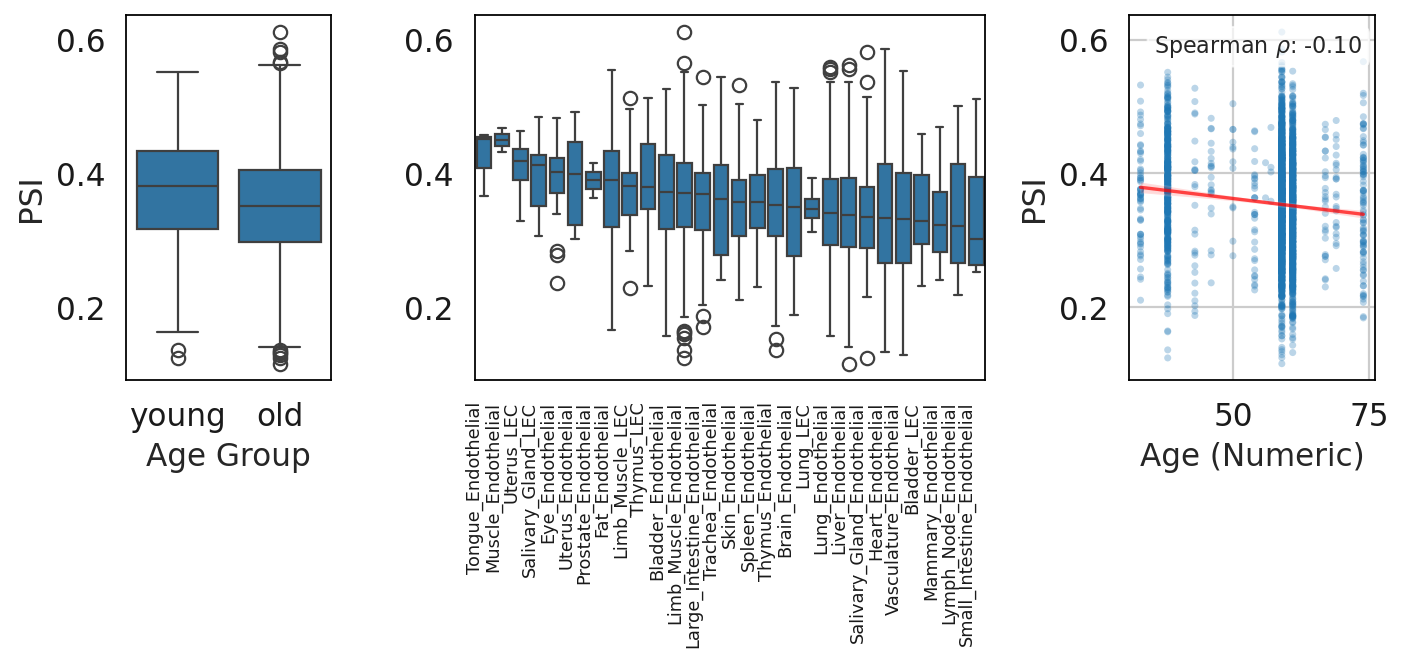

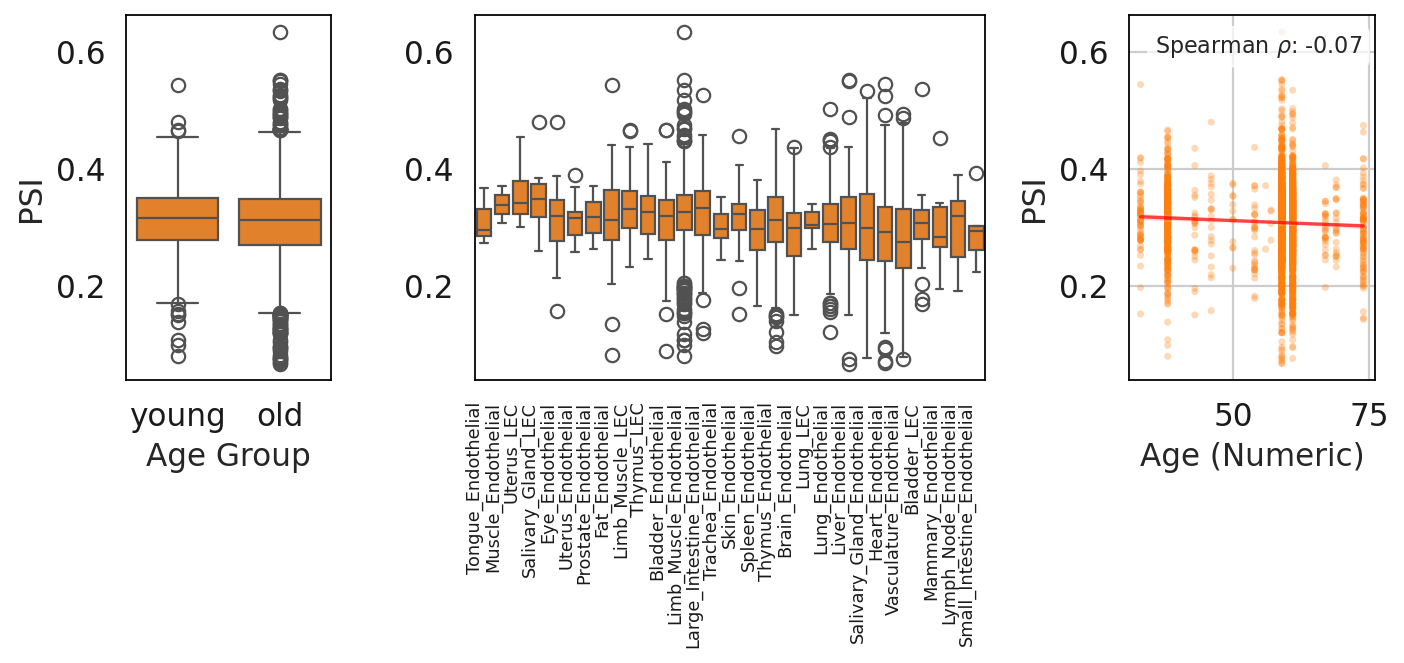

In [76]:
plot_all_junctions_in_event_final(junction_test, adata=endothelial_sj, figsize=(10, 3), output_dir=output_dir)

In [77]:
mouse_version = atse_mapping[atse_mapping["human_junction_id"] == junction_test]["mouse_junction_id"]

In [78]:
conserved_sj_markers[conserved_sj_markers["junction_id"] == mouse_version.values[0]]

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
11357,0,11357,-0.291509,0.291509,0.000433,97.0,0.97,0.03,True,0.25,...,0.1755,1.0,6269660,1100531,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated


In [79]:
atse_mapping[atse_mapping["mouse_junction_id"] == mouse_version.values[0]]

,human_junction_id,mouse_junction_id,mouse_gene,human_gene,human_event_id,mouse_event_id
2237,chr14_69767251_69768137_+,chr12_80945668_80946575_+,ENSMUSG00000021134,ENSG00000100650,ENSG00000100650.16_atse_2,ENSMUSG00000021134.17_atse_3


In [80]:
conserved_sj_markers

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
15,0,15,0.434412,0.434412,0.000688,100.0,1.00,0.00,True,0.25,...,0.9873,0.9906,24894,24810,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
19,0,19,0.420138,0.420138,0.001653,100.0,1.00,0.00,True,0.25,...,0.9876,1.0000,24681,24376,GC-AG,GC,AG,0.0,1.0,Both_SS_annotated
22,0,22,0.734593,0.734593,0.000148,100.0,1.00,0.00,True,0.25,...,0.9933,0.9864,122268,123115,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
39,0,39,0.655929,0.655929,0.000517,100.0,1.00,0.00,True,0.25,...,0.9762,0.9909,15911,15675,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
57,0,57,0.460891,0.460891,0.000445,100.0,1.00,0.00,True,0.25,...,0.9758,0.9755,76343,76368,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280231,3,69925,-0.372085,0.372085,0.000878,100.0,1.00,0.00,True,0.25,...,1.0000,0.6025,37723,62613,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
280315,3,70009,0.592805,0.592805,0.000289,100.0,1.00,0.00,True,0.25,...,0.9898,0.9090,61571,67047,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
280364,3,70058,0.465861,0.465861,0.001499,100.0,1.00,0.00,True,0.25,...,0.9314,1.0000,35104,32695,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
280366,3,70060,0.466698,0.466698,0.000430,100.0,1.00,0.00,True,0.25,...,1.0000,0.9761,31588,32361,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated


In [81]:
# let's split conserved_sj_markers into two dataframes, one for SP2 and one for SP4
conserved_sj_markers_sp1 = conserved_sj_markers[conserved_sj_markers["factor_idx"] == 0]
conserved_sj_markers_sp4 = conserved_sj_markers[conserved_sj_markers["factor_idx"] == 3]

In [82]:
# rename junction_id in conserved_sj_markers_sp1 to mouse_junction_id
conserved_sj_markers_sp1.rename(columns={"junction_id": "mouse_junction_id"}, inplace=True)
# do the same for conserved_sj_markers_sp4
conserved_sj_markers_sp4.rename(columns={"junction_id": "mouse_junction_id"}, inplace=True)

In [83]:
# rename column in correlation_df to "human_junction_id" then merge with atse_mapping on human_junction_id
correlation_df.rename(columns={"junction_id": "human_junction_id"}, inplace=True)
correlation_df = correlation_df.merge(atse_mapping, on="human_junction_id")

In [84]:
sp1_vs_human_corr = correlation_df.merge(conserved_sj_markers_sp1[["mouse_junction_id", "effect_size"]], on="mouse_junction_id")
sp4_vs_human_corr = correlation_df.merge(conserved_sj_markers_sp4[["mouse_junction_id", "effect_size"]], on="mouse_junction_id")

In [85]:
# what we actually want here is mouse correlations wtih age 

In [86]:
sp4_vs_human_corr[sp4_vs_human_corr["sig_coef"] == "neg"]

,human_junction_id,spearman_r,p_value,fdr,sig_coef,mouse_junction_id,mouse_gene,human_gene,human_event_id,mouse_event_id,effect_size
82,chr6_129642018_129710023_-,-0.050319,4.247608e-03,8.686724e-03,neg,chr10_26772696_26845931_+,ENSMUSG00000039031,ENSG00000146376,ENSG00000146376.11_atse_1,ENSMUSG00000039031.16_atse_1,0.470858
125,chr10_71822007_71825836_-,-0.084127,1.704512e-06,1.206042e-05,neg,chr10_60296002_60299097_+,ENSMUSG00000004207,ENSG00000197746,ENSG00000197746.15_atse_2,ENSMUSG00000004207.14_atse_5,0.341233
252,chr17_43216589_43216696_+,-0.054858,1.824209e-03,4.146590e-03,neg,chr11_101588993_101589097_+,ENSMUSG00000034947,ENSG00000184988,ENSG00000184988.8_atse_2,ENSMUSG00000034947.13_atse_2,0.350104
255,chr17_43642032_43643487_-,-0.063089,3.357381e-04,9.609347e-04,neg,chr11_101878729_101879260_-,ENSMUSG00000001493,ENSG00000005102,ENSG00000005102.14_atse_2,ENSMUSG00000001493.9_atse_1,0.781419
332,chr17_78692493_78698268_-,-0.060063,6.407527e-04,1.679072e-03,neg,chr11_118177296_118182219_-,ENSMUSG00000017132,ENSG00000108669,ENSG00000108669.18_atse_3,ENSMUSG00000017132.17_atse_2,0.752004
...,...,...,...,...,...,...,...,...,...,...,...
4280,chr19_10830378_10832303_+,-0.095010,6.397052e-08,9.587183e-07,neg,chr9_21505715_21507422_+,ENSMUSG00000033335,ENSG00000079805,ENSG00000079805.19_atse_5,ENSMUSG00000033335.17_atse_7,-0.291901
4286,chr19_11447618_11447692_+,-0.087734,5.989764e-07,5.197805e-06,neg,chr9_22011596_22011673_+,ENSMUSG00000003402,ENSG00000130175,ENSG00000130175.10_atse_3,ENSMUSG00000003402.14_atse_2,0.376007
4293,chr11_134248484_134249166_-,-0.062495,3.819739e-04,1.072834e-03,neg,chr9_27006447_27007157_+,ENSMUSG00000035443,ENSG00000151500,ENSG00000151500.15_atse_3,ENSMUSG00000035443.10_atse_4,-0.263213
4301,chr11_128998468_129040927_-,-0.061570,4.660183e-04,1.273747e-03,neg,chr9_32208265_32239261_+,ENSMUSG00000041444,ENSG00000134909,ENSG00000134909.19_atse_1,ENSMUSG00000041444.14_atse_1,0.678808


In [87]:
sp1_vs_human_corr[sp1_vs_human_corr["sig_coef"] == "pos"]

,human_junction_id,spearman_r,p_value,fdr,sig_coef,mouse_junction_id,mouse_gene,human_gene,human_event_id,mouse_event_id,effect_size
1,chr12_88054413_88055575_-,0.081656,3.408325e-06,2.103377e-05,pos,chr10_100567152_100568080_+,ENSMUSG00000019971,ENSG00000198707,ENSG00000198707.17_atse_14,ENSMUSG00000019971.10_atse_4,0.420138
2,chr12_85805962_85836154_-,0.083532,2.017483e-06,1.389605e-05,pos,chr10_102512584_102544805_+,ENSMUSG00000044921,ENSG00000198774,ENSG00000198774.5_atse_1,ENSMUSG00000044921.5_atse_1,0.734593
4,chr12_81369194_81374633_-,0.080789,4.325951e-06,2.517959e-05,pos,chr10_106830700_106835695_+,ENSMUSG00000053825,ENSG00000139220,ENSG00000139220.17_atse_1,ENSMUSG00000053825.15_atse_5,0.460891
6,chr12_81109704_81134815_+,0.071130,5.249779e-05,2.001951e-04,pos,chr10_107053516_107084806_-,ENSMUSG00000035948,ENSG00000111058,ENSG00000111058.8_atse_2,ENSMUSG00000035948.13_atse_2,0.790538
8,chr12_80845939_80848250_-,0.089071,4.021150e-07,3.813903e-06,pos,chr10_107380151_107382503_+,ENSMUSG00000019906,ENSG00000111052,ENSG00000111052.8_atse_1,ENSMUSG00000019906.15_atse_2,0.585809
...,...,...,...,...,...,...,...,...,...,...,...
4830,chrX_49031544_49033464_-,0.106562,1.292117e-09,5.632051e-08,pos,chrX_7771070_7772448_+,ENSMUSG00000000134,ENSG00000068323,ENSG00000068323.17_atse_3,ENSMUSG00000000134.17_atse_4,0.366140
4831,chrX_48983440_48983774_-,0.056487,1.326553e-03,3.140388e-03,pos,chrX_7809988_7810252_+,ENSMUSG00000031153,ENSG00000068400,ENSG00000068400.14_atse_4,ENSMUSG00000031153.16_atse_5,0.300363
4837,chrX_68210282_68212107_-,0.060023,6.462159e-04,1.688738e-03,pos,chrX_98712470_98714106_-,ENSMUSG00000031214,ENSG00000079482,ENSG00000079482.14_atse_3,ENSMUSG00000031214.13_atse_1,0.613631
4838,chrY_13360528_13366266_-,0.083962,1.786381e-06,1.256186e-05,pos,chrY_1171002_1174727_-,ENSMUSG00000068457,ENSG00000183878,ENSG00000183878.16_atse_6,ENSMUSG00000068457.14_atse_6,0.516744


In [88]:
2253+83

2336

Text(0, 0.5, 'Human Spearman rho')

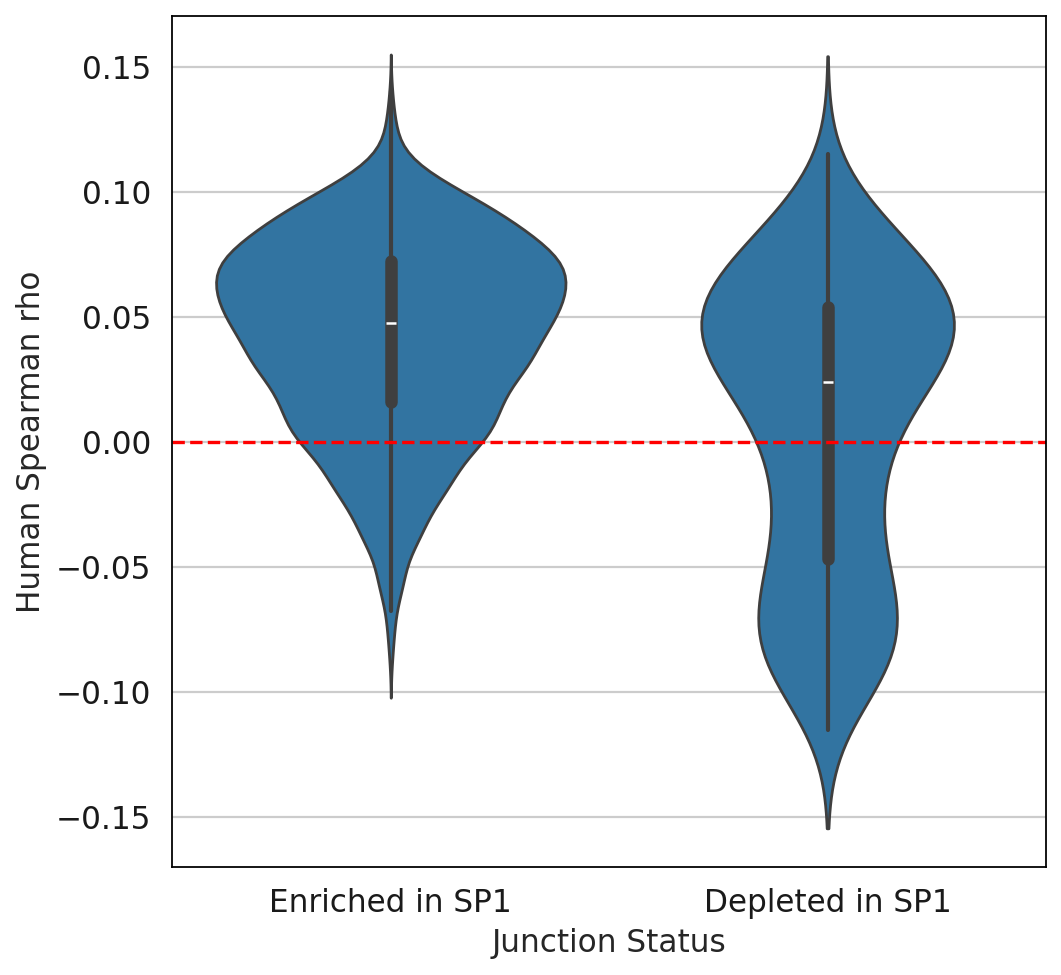

In [89]:
# add a column sp1_vs_human_corr["junction_status"] enriched in SP1 or depleted in SP1 based on the sign of the effect size 
sp1_vs_human_corr["junction_status"] = np.where(sp1_vs_human_corr["effect_size"] > 0, "Enriched in SP1", "Depleted in SP1")
# now make violin plot of sp1_vs_human_corr["human_spearman_r"] by sp1_vs_human_corr["junction_status"]
sns.violinplot(x="junction_status", y="spearman_r", data=sp1_vs_human_corr)
# add dashed red line at 0
plt.axhline(0, color="red", linestyle="--")
# add x axis label
plt.xlabel("Junction Status")
# add y axis label
plt.ylabel("Human Spearman rho")

Text(0, 0.5, 'Human Spearman rho')

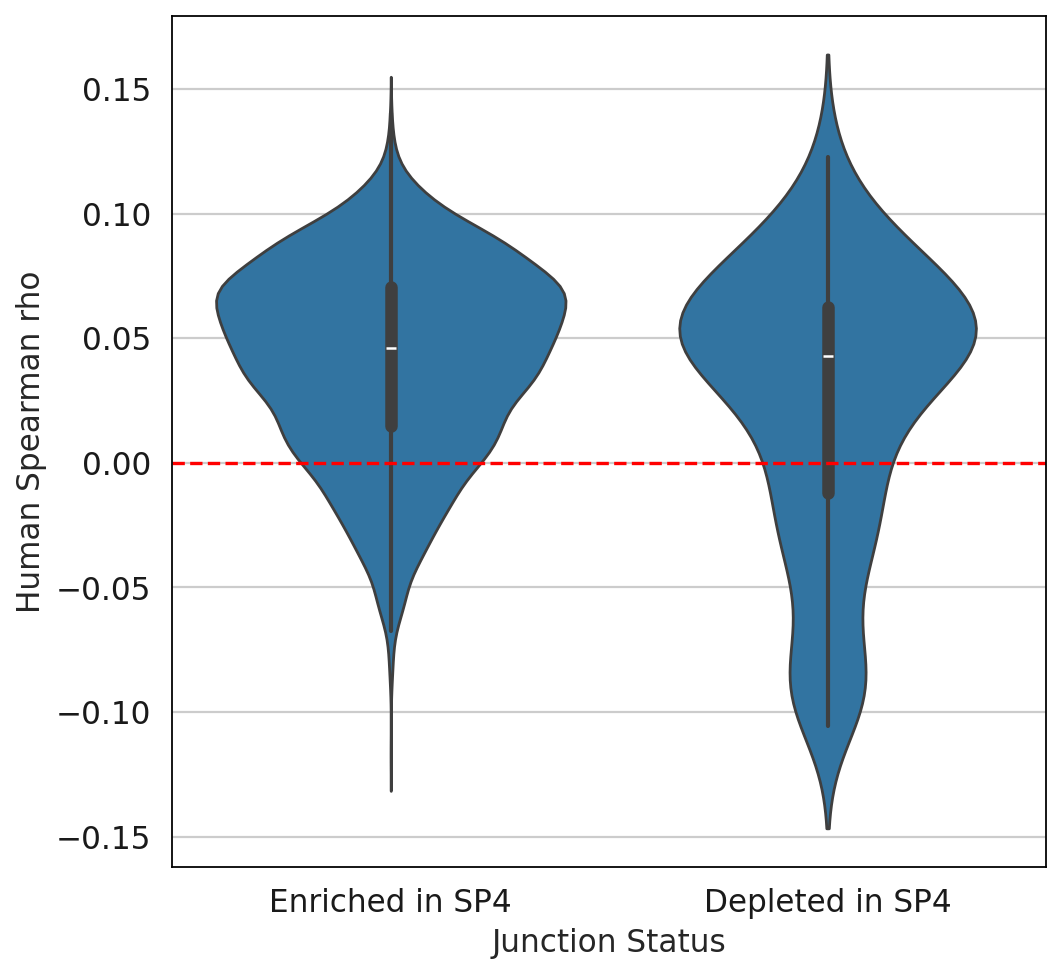

In [90]:
# add a column sp4_vs_human_corr["junction_status"] enriched in SP4 or depleted in SP4 based on the sign of the effect size 
sp4_vs_human_corr["junction_status"] = np.where(sp4_vs_human_corr["effect_size"] > 0, "Enriched in SP4", "Depleted in SP4")
# now make violin plot of sp4_vs_human_corr["human_spearman_r"] by sp4_vs_human_corr["junction_status"]
sns.violinplot(x="junction_status", y="spearman_r", data=sp4_vs_human_corr)
# add dashed red line at 0
plt.axhline(0, color="red", linestyle="--")
# add x axis label
plt.xlabel("Junction Status")
# add y axis label
plt.ylabel("Human Spearman rho")

In [91]:
# Get SRSF5 expression for endothelial cells
# Filter adata for endothelial cells
endo_cells = ge_adata.obs["broad_cell_type"].str.lower().str.contains("Endothelial")
endo_adata = ge_adata[endo_cells]
endo_adata

View of AnnData object with n_obs × n_vars = 0 × 11470
    obs: 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'broad_cell_type', 'library_size', 'batch', 'cell_id_backup', 'cell_id_index', 'cell_id_clean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'medium_cell_type', 'tissue_clean'
    var: 'gene_symbol', 'gene_id', 'gene_name', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'gene_biotype', 'clean_gene_id', 'is_rRNA', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'RBP_gene', 'is_hvg', 'is_rbp', 'aging_gene', 'senescence_gene', 'high_confidence_aging_gene'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'gene_selection', 'leiden_scVI', 'leiden_scVI_colors', 'leiden_scVI_params', 'neighbors', 'scvi_linear', 'umap'
    obsm: 

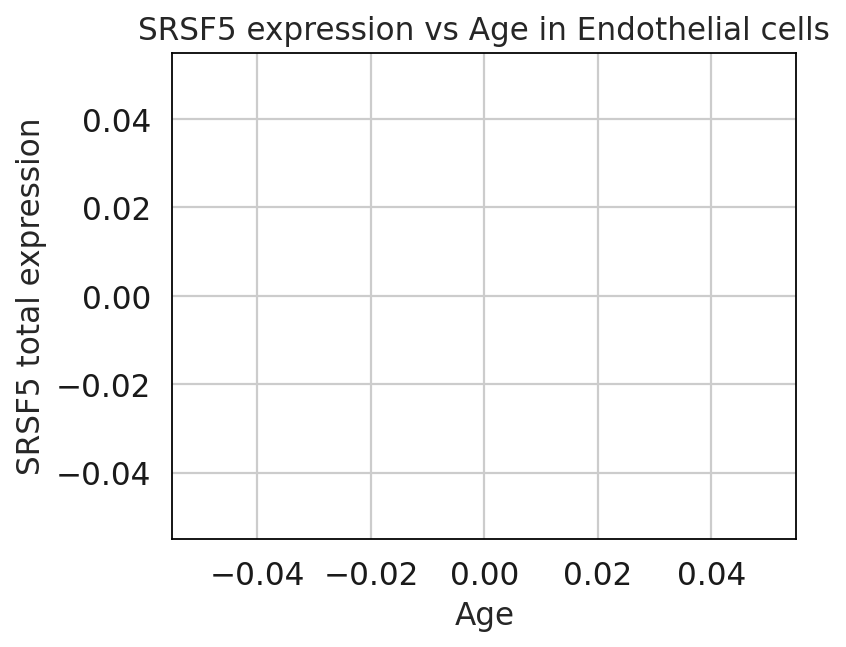

In [92]:
# Get SRSF5 total expression for these cells
# The expression matrix is assumed to be in .X and genes in ge_adata.var
if "SRSF5" in ge_adata.var["gene_name"].values:
    srsf5_gene_idx = ge_adata.var.query('gene_name == "SRSF5"').index[0]
elif "SRSF5" in ge_adata.var_names:
    srsf5_gene_idx = "SRSF5"
else:
    raise ValueError("SRSF5 not found in gene names!")

# Extract age and SRSF5 expression
age_vals = endo_adata.obs["age"].astype(float)
if isinstance(srsf5_gene_idx, int):
    srsf5_expr = endo_adata.X[:, srsf5_gene_idx].toarray().flatten() if hasattr(endo_adata.X, "toarray") else endo_adata.X[:, srsf5_gene_idx]
else:
    srsf5_expr = endo_adata[:, srsf5_gene_idx].X.toarray().flatten() if hasattr(endo_adata[:, srsf5_gene_idx].X, "toarray") else endo_adata[:, srsf5_gene_idx].X

# Scatter plot: age vs SRSF5 expression
plt.figure(figsize=(5,4))
plt.scatter(age_vals, srsf5_expr, alpha=0.5)
plt.xlabel("Age")
plt.ylabel("SRSF5 total expression")
plt.title("SRSF5 expression vs Age in Endothelial cells")
plt.show()

In [93]:
# subset ge_adata to endothelial_sj cells 
ge_adata_endo = ge_adata_subset[endothelial_sj.obs.cell_id_clean]
ge_adata_endo
# add x axis label

View of AnnData object with n_obs × n_vars = 3227 × 11470
    obs: 'donor', 'sex', 'age', 'dataset', 'tissue', 'cell_type', 'broad_cell_type', 'library_size', 'batch', 'cell_id_backup', 'cell_id_index', 'cell_id_clean', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'medium_cell_type', 'tissue_clean', 'tissue_aligned', 'tissue_celltype_aligned', 'aging_score'
    var: 'gene_symbol', 'gene_id', 'gene_name', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'gene_biotype', 'clean_gene_id', 'is_rRNA', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'RBP_gene', 'is_hvg', 'is_rbp', 'aging_gene', 'senescence_gene', 'high_confidence_aging_gene'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'gene_selection', 'leiden_scVI', 'leiden_scVI_colors', 'lei

In [94]:
ge_adata_endo.var_names.get_loc("SRSF5")

408

In [95]:
endothelial_sj.obs

,cell_id,donor,sex,age,dataset,tissue,cell_type,cell_id_index,cell_id_clean,total_junction_reads,...,tissue_str,cell_type_map,tissue_map,tissue_aligned,broad_cell_type,tissue_celltype_aligned,aging_score,broad_cell_type_with_counts,age_group,perplexity
437,F1S4_160721_059_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,437,F1S4_160721_059_H01,31303,...,MTG,Endothelial,MTG,Brain,Endothelial,Brain_Endothelial,0.000068,"Endothelial (n=3,227)",old,6.826968
643,F1S4_160721_090_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,643,F1S4_160721_090_H01,55679,...,MTG,Endothelial,MTG,Brain,Endothelial,Brain_Endothelial,0.000068,"Endothelial (n=3,227)",old,5.240908
807,F1S4_160721_114_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,807,F1S4_160721_114_H01,39635,...,MTG,Endothelial,MTG,Brain,Endothelial,Brain_Endothelial,0.000089,"Endothelial (n=3,227)",old,9.052136
1494,F1S4_160802_105_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,1494,F1S4_160802_105_H01,28774,...,MTG,Endothelial,MTG,Brain,Endothelial,Brain_Endothelial,0.000080,"Endothelial (n=3,227)",old,4.848044
1591,F1S4_160802_119_H01,H200.1030,M,54,allen_brain,MTG,Endothelial,1591,F1S4_160802_119_H01,71263,...,MTG,Endothelial,MTG,Brain,Endothelial,Brain_Endothelial,0.000091,"Endothelial (n=3,227)",old,7.920586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74557,TSP7_TSP7_smartseq2_B134153_B114729_Spleen_NA....,TSP7,F,69,tabula_sapiens,Spleen,endothelial cell,74557,TSP7_donor_B134153_H16_B114729_H16_Spleen_Stromal,300235,...,Spleen,endothelial cell,Spleen,Spleen,Endothelial,Spleen_Endothelial,0.000174,"Endothelial (n=3,227)",old,6.692993
74897,TSP7_TSP7_smartseq2_B134155_B114746_LymphNode_...,TSP7,F,69,tabula_sapiens,Lymph_Node,endothelial cell,74897,TSP7_donor_B134155_C9_B114746_C9_LymphNode_Str...,11537,...,Lymph_Node,endothelial cell,Lymph_Node,Lymph_Node,Endothelial,Lymph_Node_Endothelial,0.000125,"Endothelial (n=3,227)",old,7.408162
75663,TSP7_TSP7_smartseq2_B134164_B133901_Tongue_ant...,TSP7,F,69,tabula_sapiens,Tongue,endothelial cell,75663,TSP7_donor_B134164_B6_B133901_B6_Tongue_Immune,35169,...,Tongue,endothelial cell,Tongue,Tongue,Endothelial,Tongue_Endothelial,0.000065,"Endothelial (n=3,227)",old,6.441665
76692,TSP8_TSP8_smartseq2_B134137_B134703_Prostate_N...,TSP8,M,56,tabula_sapiens,Prostate,endothelial cell,76692,TSP8_donor_B134137_D12_B134703_D12_Prostate_En...,171473,...,Prostate,endothelial cell,Prostate,Prostate,Endothelial,Prostate_Endothelial,0.000297,"Endothelial (n=3,227)",old,6.447479


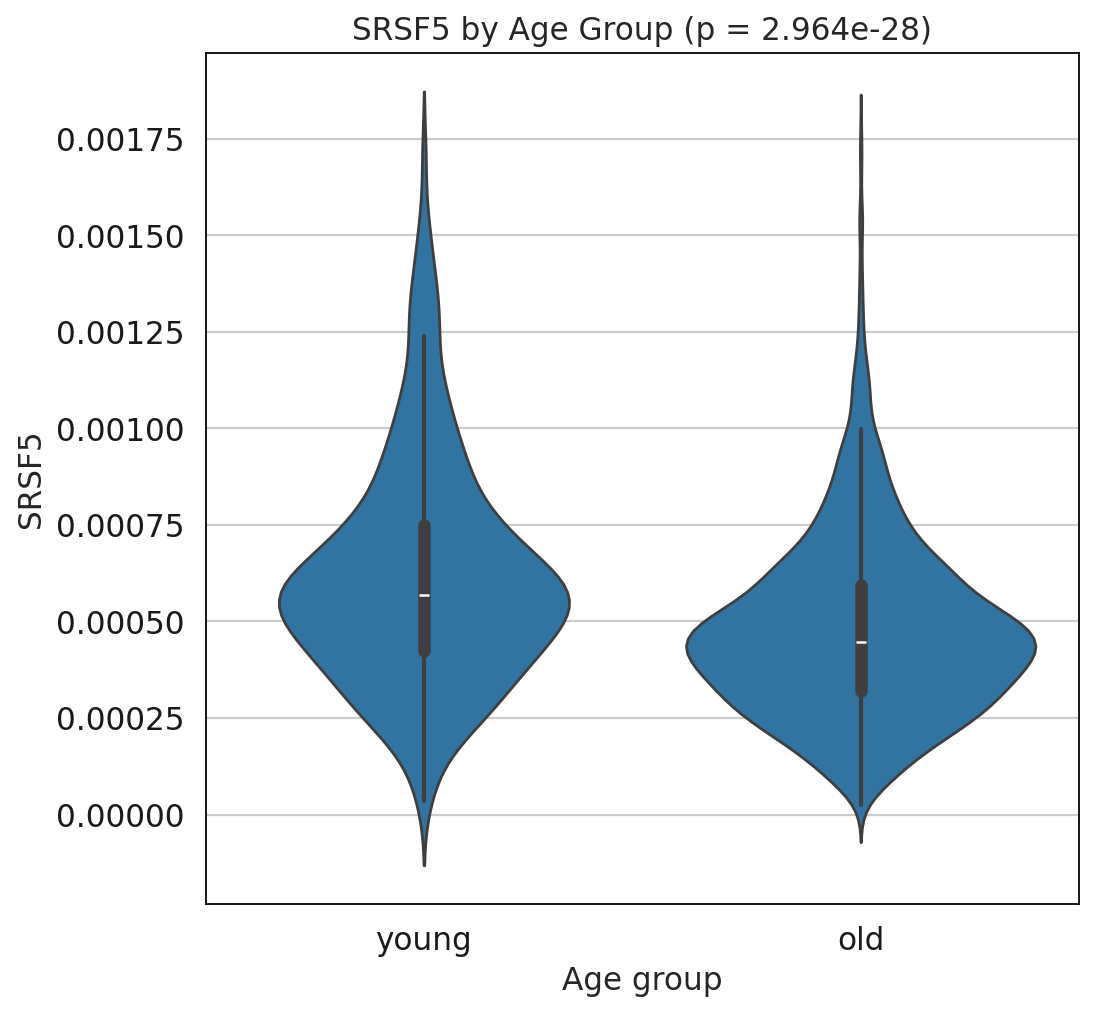

In [96]:
# add age group to ge_adata_endo from endothelial_sj.obs["age_group"]
ge_adata_endo.obs["age_group"] = endothelial_sj.obs["age_group"].values
ge_adata_endo.obs["SRSF5"] = ge_adata_endo.obsm["X_normalized_scVI_linear"]["SRSF5"]

# Ensure 'age_group' is categorical with 'young' first, 'old' second
ge_adata_endo.obs["age_group"] = pd.Categorical(
    ge_adata_endo.obs["age_group"], categories=["young", "old"], ordered=True
)

# Violin plot: young first, then old
sns.violinplot(
    x="age_group",
    y="SRSF5",
    data=ge_adata_endo.obs,
    order=["young", "old"]
)
plt.ylabel("SRSF5")
plt.xlabel("Age group")

# Wilcoxon rank-sum test (Mann-Whitney U test) for young vs old
from scipy.stats import mannwhitneyu

srsf5_young = ge_adata_endo.obs.loc[ge_adata_endo.obs["age_group"] == "young", "SRSF5"]
srsf5_old = ge_adata_endo.obs.loc[ge_adata_endo.obs["age_group"] == "old", "SRSF5"]

stat, pvalue = mannwhitneyu(srsf5_young, srsf5_old, alternative="two-sided")

# Add p-value to the plot
plt.title(f"SRSF5 by Age Group (p = {pvalue:.3e})")

plt.show()